# Descrição do Dataset: [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/data)

O dataset utilizado nesta competição é uma versão derivativa e sintética que simula um cenário de ficção científica: o objetivo é prever se um passageiro foi transportado para uma dimensão alternativa após a colisão da nave ***Spaceship Titanic*** com uma anomalia espaço-temporal.

Para construir as previsões, o conjunto de dados fornece registros pessoais recuperados do sistema de computadores danificado da nave.

## Arquivos do Projeto

* **`train.csv`**: Registros pessoais de aproximadamente dois terços (~8.700) dos passageiros, utilizados como dados de treino. Contém a variável alvo (`Transported`).
* **`test.csv`**: Registros pessoais do terço restante (~4.300) dos passageiros, utilizados como dados de teste. O objetivo é prever o valor de `Transported` para este conjunto.

---

## Dicionário de Dados (Variáveis)

O conjunto de dados possui as seguintes colunas informativas:

## Identificação e Perfil do Passageiro

* **`PassengerId`**: Um identificador único para cada passageiro no formato `gggg_pp`, onde:
* `gggg` indica o grupo com o qual o passageiro está viajando (frequentemente membros da mesma família).
* `pp` é o número do passageiro dentro daquele grupo.

* **`Name`**: O nome e sobrenome do passageiro.
* **`Age`**: A idade do passageiro.

## Detalhes da Viagem

* **`HomePlanet`**: O planeta de origem do passageiro.
* **`Destination`**: O planeta de destino onde o passageiro iria desembarcar.
* **`Cabin`**: O número da cabine onde o passageiro estava hospedado. Segue o formato `deck/num/side` (convés/número/lado), onde o lado pode ser **P** (*Port* - Bombordo) ou **S** (*Starboard* - Estibordo).
* **`CryoSleep`**: Indica se o passageiro optou por ser colocado em animação suspensa (criossono) durante a viagem. Passageiros em criossono ficam confinados em suas cabines.
* **`VIP`**: Indica se o passageiro pagou por serviços VIP especiais durante a viagem.

## Despesas a Bordo

Valor total que o passageiro gastou em cada uma das muitas comodidades de luxo da Spaceship Titanic:

* **`RoomService`**: Serviço de quarto.
* **`FoodCourt`**: Praça de alimentação.
* **`ShoppingMall`**: Shopping center.
* **`Spa`**: Centro de relaxamento/Spa.
* **`VRDeck`**: Deck de Realidade Virtual.

## Variável Alvo (*Target*)

* **`Transported`**: Indica se o passageiro foi transportado para outra dimensão (**True** ou **False**). Esta é a variável que o modelo deve prever.

# Setup do ambiente

Nesta seção iremos:
- Importar as bibliotecas necessárias para a análise;
- Definir configurações globais de visualização;
- Localizar os caminhos do projeto com `src.roots`;
- Carregar os arquivos locais de treino e teste.


In [ ]:
# Manipulação básica de dados
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo consistente para todos os gráficos
sns.set_theme(style="whitegrid")

# Permite executar o notebook a partir da raiz do projeto ou da pasta notebooks/.
PROJECT_ROOT_HINT = Path.cwd()
if not (PROJECT_ROOT_HINT / "src").exists():
    PROJECT_ROOT_HINT = PROJECT_ROOT_HINT.parent

if str(PROJECT_ROOT_HINT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT_HINT))

from src.roots import TEST_DATA_PATH, TRAIN_DATA_PATH  # noqa: E402


In [ ]:
train = pd.read_csv(TRAIN_DATA_PATH)
test = pd.read_csv(TEST_DATA_PATH)

print("Tabela com as primeiras linhas do conjunto de treino")

# Visualização rápida das primeiras linhas
train.head()


# Análise Exploratória dos Dados (EDA)

Nesta seção, a exploração foi reorganizada para responder perguntas de modelagem em uma ordem mais natural: primeiro entendemos o dataset, depois avaliamos qualidade dos dados, relações com o alvo e hipóteses de engenharia de atributos.

Para a EDA, criaremos uma cópia enriquecida do treino com `PassengerGroup`, `PassengerNum`, `CabinDeck`, `CabinNum`, `CabinSide`, `FamilyName` e `TotalSpend`. A mesma função será reaproveitada no pré-processamento para evitar divergência entre análise e modelagem.


In [ ]:
# Pré-processamento pontual para simplificar a EDA
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
target = "Transported"

def split_cabin_passenger(df):
    out = df.copy()

    if "PassengerId" in out.columns:
        passenger_parts = out["PassengerId"].str.split("_", expand=True)
        out["PassengerGroup"] = passenger_parts[0]
        out["PassengerNum"] = pd.to_numeric(passenger_parts[1], errors="coerce")

    if "Cabin" in out.columns:
        cabin_parts = out["Cabin"].str.split("/", expand=True)
        out["CabinDeck"] = cabin_parts[0]
        out["CabinNum"] = pd.to_numeric(cabin_parts[1], errors="coerce")
        out["CabinSide"] = cabin_parts[2]

    if "Name" in out.columns:
        out["FamilyName"] = out["Name"].str.strip().str.rsplit(" ", n=1).str[-1]

    available_spend_cols = [col for col in spend_cols if col in out.columns]
    if available_spend_cols:
        out["TotalSpend"] = out[available_spend_cols].sum(axis=1, min_count=1)

    out = out.drop(columns=["PassengerId", "Cabin", "Name"], errors="ignore")
    return out

eda = split_cabin_passenger(train)
eda_test = split_cabin_passenger(test)

# Variáveis auxiliares usadas apenas nas análises exploratórias.
eda["SpentSomething"] = eda[spend_cols].gt(0).any(axis=1)
eda["HasMissingSpend"] = eda[spend_cols].isna().any(axis=1)

print("Prévia das variáveis derivadas para a EDA")
display(
    eda[[
        "PassengerGroup",
        "PassengerNum",
        "FamilyName",
        "CabinDeck",
        "CabinNum",
        "CabinSide",
        "TotalSpend",
        "SpentSomething",
    ]].head()
)


Prévia das variáveis derivadas para a EDA


,PassengerGroup,PassengerNum,FamilyName,CabinDeck,CabinNum,CabinSide,TotalSpend,SpentSomething
0,0001,1,Ofracculy,B,0.0,P,0.0,False
1,0002,1,Vines,F,0.0,S,736.0,True
2,0003,1,Susent,A,0.0,S,10383.0,True
3,0003,2,Susent,A,0.0,S,5176.0,True
4,0004,1,Santantines,F,1.0,S,1091.0,True


## Entendimento básico do dataset

Esta primeira parte estabelece o tamanho da base, os tipos de dados, estatísticas descritivas e o balanceamento do alvo `Transported`. Essa visão evita que as próximas análises fiquem soltas: antes de procurar padrões, precisamos saber a escala e a composição dos dados.


In [ ]:
# Dimensões e tipos principais
overview = pd.DataFrame(
    {
        "dataset": ["train bruto", "test bruto", "train EDA"],
        "linhas": [train.shape[0], test.shape[0], eda.shape[0]],
        "colunas": [train.shape[1], test.shape[1], eda.shape[1]],
    }
)

print("Dimensões dos datasets")
display(overview)

print("Info do treino bruto")
train.info()

print("Info do treino enriquecido para EDA")
eda.info()


Dimensões dos datasets


,dataset,linhas,colunas
0,train bruto,8693,14
1,test bruto,4277,13
2,train EDA,8693,20


Info do treino bruto
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
Info do treino enriquecido para EDA
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 co

In [ ]:
# Estatísticas descritivas numéricas e categóricas
print("Estatísticas descritivas das variáveis numéricas")
display(eda.describe(include=[np.number]).T.round(2))

print("Resumo das variáveis categóricas e booleanas")
categorical_summary = eda.select_dtypes(include=["str", "bool"]).describe().T
display(categorical_summary)


Estatísticas descritivas das variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.83,14.49,0.0,19.00,27.0,38.0,79.0
RoomService,8512.0,224.69,666.72,0.0,0.00,0.0,47.0,14327.0
FoodCourt,8510.0,458.08,1611.49,0.0,0.00,0.0,76.0,29813.0
ShoppingMall,8485.0,173.73,604.70,0.0,0.00,0.0,27.0,23492.0
Spa,8510.0,311.14,1136.71,0.0,0.00,0.0,59.0,22408.0
VRDeck,8505.0,304.85,1145.72,0.0,0.00,0.0,46.0,24133.0
PassengerNum,8693.0,1.52,1.05,1.0,1.00,1.0,2.0,8.0
CabinNum,8494.0,600.37,511.87,0.0,167.25,427.0,999.0,1894.0
TotalSpend,8693.0,1440.87,2803.05,0.0,0.00,716.0,1441.0,35987.0


Resumo das variáveis categóricas e booleanas


,count,unique,top,freq
HomePlanet,8492,3,Earth,4602
Destination,8511,3,TRAPPIST-1e,5915
Transported,8693,2,True,4378
PassengerGroup,8693,6217,0984,8
CabinDeck,8494,8,F,2794
CabinSide,8494,2,S,4288
SpentSomething,8693,2,True,5040
HasMissingSpend,8693,2,False,7785


Tabela com contagem e percentual do atributo alvo


,count,pct
Transported,,
True,4378,50.36
False,4315,49.64


Gráfico com distribuição do atributo alvo


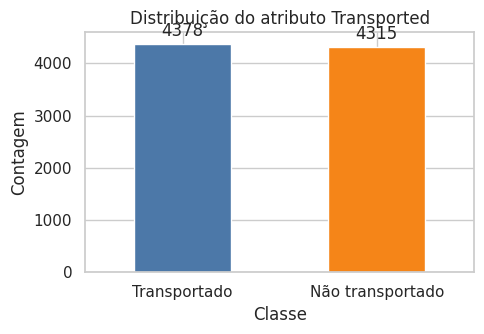

In [ ]:
# Distribuição do atributo alvo para checar balanceamento de classes
target_counts = eda[target].value_counts(dropna=False).rename("count")
target_pct = eda[target].value_counts(normalize=True, dropna=False).mul(100).round(2).rename("pct")
target_summary = pd.concat([target_counts, target_pct], axis=1)

print("Tabela com contagem e percentual do atributo alvo")
display(target_summary)

print("Gráfico com distribuição do atributo alvo")
fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ["#4C78A8", "#F58518"]
target_counts.rename(index={False: "Não transportado", True: "Transportado"}).plot(
    kind="bar",
    ax=ax,
    color=colors,
)
ax.set_title("Distribuição do atributo Transported")
ax.set_xlabel("Classe")
ax.set_ylabel("Contagem")
ax.bar_label(ax.containers[0], padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Valores ausentes

Aqui avaliamos tanto a quantidade de valores nulos quanto a quantidade de valores não nulos por atributo. Como os percentuais de ausência são pequenos, a escolha de imputação no pré-processamento pode ser simples, mas ainda precisa ser consistente entre treino e teste.


In [ ]:
# Função auxiliar: resumo de valores nulos e não nulos por coluna
def missing_summary(df):
    missing = df.isna().sum()
    non_null = df.notna().sum()
    out = pd.DataFrame(
        {
            "non_null_count": non_null,
            "missing_count": missing,
            "missing_pct": (missing / len(df) * 100).round(2),
        }
    )
    return out.sort_values(["missing_count", "missing_pct"], ascending=False)

missing_eda = missing_summary(eda)
missing_test = missing_summary(eda_test)

print("Valores ausentes no treino")
display(missing_eda[missing_eda["missing_count"] > 0])

print("Valores ausentes no teste")
display(missing_test[missing_test["missing_count"] > 0])


Valores ausentes no treino


,non_null_count,missing_count,missing_pct
CryoSleep,8476,217,2.50
ShoppingMall,8485,208,2.39
VIP,8490,203,2.34
HomePlanet,8492,201,2.31
FamilyName,8493,200,2.30
CabinDeck,8494,199,2.29
CabinNum,8494,199,2.29
CabinSide,8494,199,2.29
VRDeck,8505,188,2.16
FoodCourt,8510,183,2.11


Valores ausentes no teste


,non_null_count,missing_count,missing_pct
FoodCourt,4171,106,2.48
Spa,4176,101,2.36
CabinDeck,4177,100,2.34
CabinNum,4177,100,2.34
CabinSide,4177,100,2.34
ShoppingMall,4179,98,2.29
FamilyName,4183,94,2.20
CryoSleep,4184,93,2.17
VIP,4184,93,2.17
Destination,4185,92,2.15


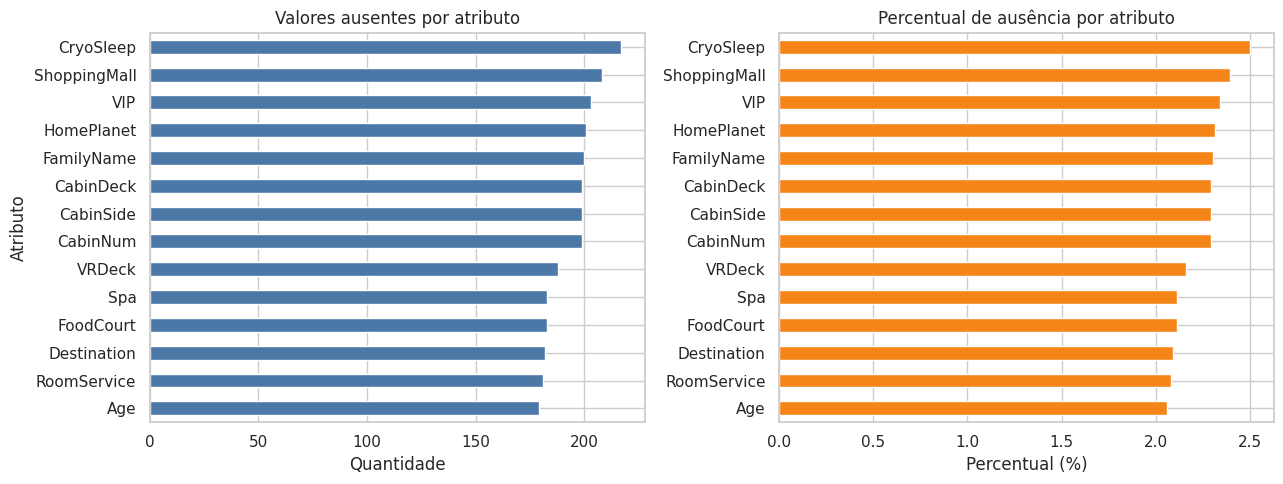

In [ ]:
# Visualização da nulidade por atributo no treino
missing_to_plot = missing_eda[missing_eda["missing_count"] > 0].sort_values("missing_count")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

missing_to_plot["missing_count"].plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Valores ausentes por atributo")
axes[0].set_xlabel("Quantidade")
axes[0].set_ylabel("Atributo")

missing_to_plot["missing_pct"].plot(kind="barh", ax=axes[1], color="#F58518")
axes[1].set_title("Percentual de ausência por atributo")
axes[1].set_xlabel("Percentual (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Relações lógicas entre atributos e target

Nesta subseção, olhamos quais atributos se relacionam diretamente com `Transported`. Para variáveis categóricas de baixa cardinalidade, usamos taxa de transporte por categoria. Para variáveis numéricas, usamos correlação como uma primeira leitura linear, sem tratá-la como causalidade.


In [ ]:
# Taxa de transporte por atributo categórico
def target_rate_by(df, col):
    summary = (
        df.groupby(col, dropna=False)[target]
        .agg(qtd_passageiros="count", taxa_transporte="mean")
        .sort_values("taxa_transporte", ascending=False)
    )
    summary["taxa_transporte_pct"] = (summary["taxa_transporte"] * 100).round(2)
    return summary.drop(columns="taxa_transporte")

categorical_rate_cols = ["HomePlanet", "Destination", "CryoSleep", "VIP", "CabinDeck", "CabinSide"]

for col in categorical_rate_cols:
    print(f"Taxa de transporte por {col}")
    display(target_rate_by(eda, col))


Taxa de transporte por HomePlanet


,qtd_passageiros,taxa_transporte_pct
HomePlanet,,
Europa,2131,65.88
Mars,1759,52.30
NaN,201,51.24
Earth,4602,42.39


Taxa de transporte por Destination


,qtd_passageiros,taxa_transporte_pct
Destination,,
55 Cancri e,1800,61.00
NaN,182,50.55
PSO J318.5-22,796,50.38
TRAPPIST-1e,5915,47.12


Taxa de transporte por CryoSleep


,qtd_passageiros,taxa_transporte_pct
CryoSleep,,
True,3037,81.76
NaN,217,48.85
False,5439,32.89


Taxa de transporte por VIP


,qtd_passageiros,taxa_transporte_pct
VIP,,
NaN,203,51.23
False,8291,50.63
True,199,38.19


Taxa de transporte por CabinDeck


,qtd_passageiros,taxa_transporte_pct
CabinDeck,,
B,779,73.43
C,747,68.01
G,2559,51.62
NaN,199,50.25
A,256,49.61
F,2794,43.99
D,478,43.31
E,876,35.73
T,5,20.00


Taxa de transporte por CabinSide


,qtd_passageiros,taxa_transporte_pct
CabinSide,,
S,4288,55.50
NaN,199,50.25
P,4206,45.13


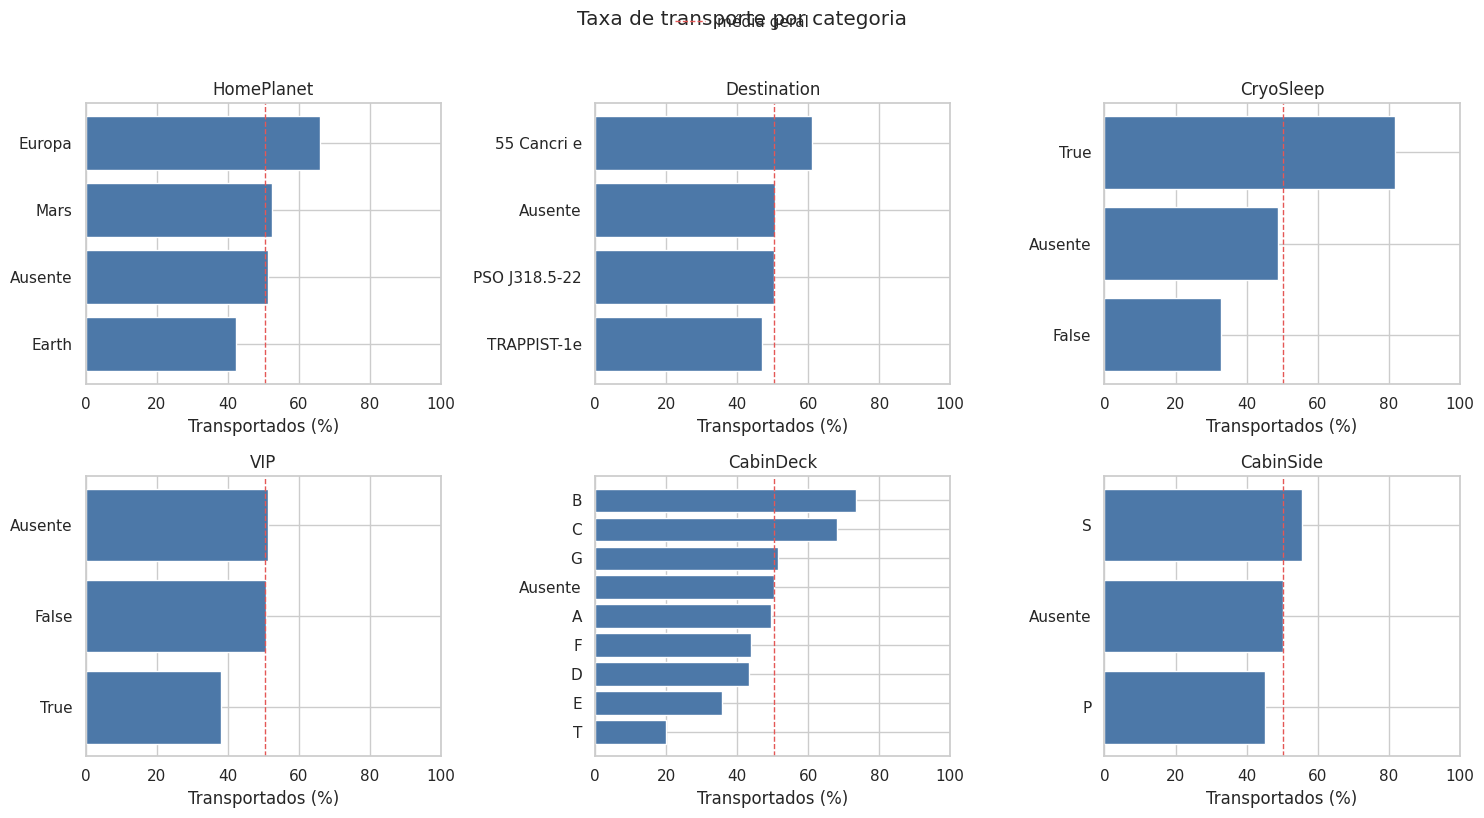

In [ ]:
# Gráficos de taxa de transporte por categorias principais
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
base_rate = eda[target].mean() * 100

for ax, col in zip(axes.ravel(), categorical_rate_cols):
    rate = target_rate_by(eda, col).sort_values("taxa_transporte_pct")
    labels = ["Ausente" if pd.isna(value) else str(value) for value in rate.index]
    ax.barh(labels, rate["taxa_transporte_pct"].to_numpy(), color="#4C78A8")
    ax.axvline(base_rate, color="#E45756", linestyle="--", linewidth=1, label="média geral")
    ax.set_title(col)
    ax.set_xlabel("Transportados (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=1, frameon=False)
fig.suptitle("Taxa de transporte por categoria", y=1.02)
plt.tight_layout()
plt.show()


Correlação das variáveis numéricas com Transported


,corr_com_target
RoomService,-0.245
Spa,-0.221
VRDeck,-0.207
TotalSpend,-0.200
Age,-0.075
PassengerNum,0.066
FoodCourt,0.047
CabinNum,-0.045
ShoppingMall,0.010


Heatmap de correlações numéricas


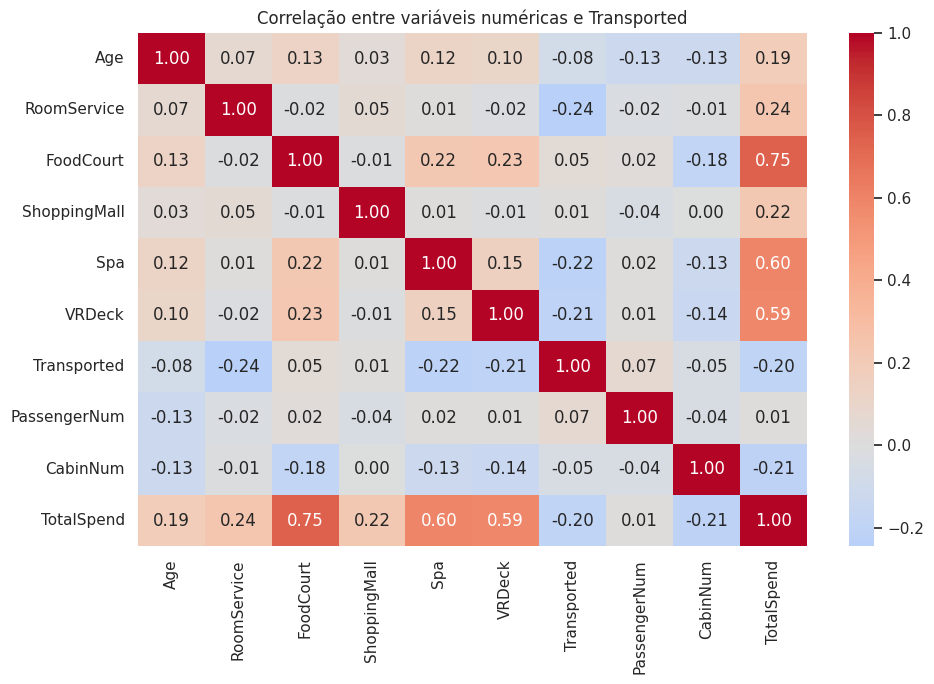

In [ ]:
# Correlação numérica com o alvo e entre atributos numéricos
corr_data = eda.copy()
corr_data[target] = corr_data[target].astype(int)

numeric_cols_for_corr = corr_data.select_dtypes(include="number").columns
corr = corr_data[numeric_cols_for_corr].corr()

print("Correlação das variáveis numéricas com Transported")
target_corr = corr[target].drop(target).sort_values(key=lambda values: values.abs(), ascending=False)
display(target_corr.to_frame("corr_com_target").round(3))

print("Heatmap de correlações numéricas")
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlação entre variáveis numéricas e Transported")
plt.tight_layout()
plt.show()


## Relações lógicas entre atributos de gastos e TotalSpend

As cinco colunas de gastos (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) são esparsas e com muitos zeros. Por isso, avaliamos `TotalSpend` como uma variável agregada. A pergunta prática para o pré-processamento é: podemos usar `TotalSpend` e remover as colunas individuais para reduzir redundância?


In [ ]:
# Resumo dos gastos individuais e do gasto total
spend_summary = pd.DataFrame(
    {
        "missing_count": eda[spend_cols].isna().sum(),
        "zero_pct": eda[spend_cols].eq(0).mean().mul(100),
        "positive_pct": eda[spend_cols].gt(0).mean().mul(100),
        "median": eda[spend_cols].median(),
        "mean": eda[spend_cols].mean(),
    }
).round(2)

print("Resumo dos atributos de gastos")
display(spend_summary)

print("Resumo de TotalSpend")
display(eda["TotalSpend"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame().T.round(2))

Resumo dos atributos de gastos


,missing_count,zero_pct,positive_pct,median,mean
RoomService,181,64.16,33.76,0.0,224.69
FoodCourt,183,62.76,35.13,0.0,458.08
ShoppingMall,208,64.27,33.34,0.0,173.73
Spa,183,61.24,36.65,0.0,311.14
VRDeck,188,63.21,34.63,0.0,304.85


Resumo de TotalSpend


,count,mean,std,min,25%,50%,75%,90%,95%,max
TotalSpend,8693.0,1440.87,2803.05,0.0,0.0,716.0,1441.0,3838.4,6457.6,35987.0


Correlação com Transported


,corr_com_target
RoomService,-0.245
Spa,-0.221
VRDeck,-0.207
TotalSpend,-0.200
FoodCourt,0.047
ShoppingMall,0.010


Correlação com TotalSpend


,corr_com_total_spend
FoodCourt,0.745
Spa,0.597
VRDeck,0.586
RoomService,0.238
ShoppingMall,0.222
Transported,-0.200


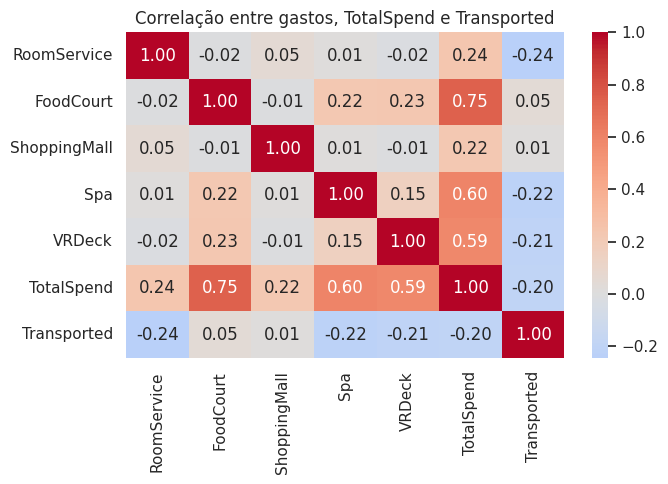

In [ ]:
# Correlações entre gastos, TotalSpend e Transported
spend_corr_data = eda[spend_cols + ["TotalSpend", target]].copy()
spend_corr_data[target] = spend_corr_data[target].astype(int)
spend_corr = spend_corr_data.corr()

print("Correlação com Transported")
display(spend_corr[target].drop(target).sort_values(key=lambda values: values.abs(), ascending=False).to_frame("corr_com_target").round(3))

print("Correlação com TotalSpend")
display(spend_corr["TotalSpend"].drop("TotalSpend").sort_values(key=lambda values: values.abs(), ascending=False).to_frame("corr_com_total_spend").round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(spend_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlação entre gastos, TotalSpend e Transported")
plt.tight_layout()
plt.show()


**Leitura para o pré-processamento:** `TotalSpend` resume bem o comportamento geral de gasto e reduz cinco colunas para uma. Ainda assim, os serviços individuais não têm exatamente o mesmo sinal: `RoomService`, `Spa` e `VRDeck` aparecem mais negativos em relação ao alvo, enquanto `FoodCourt` e `ShoppingMall` são mais fracos. Para uma primeira modelagem mais simples, usaremos `TotalSpend` e removeremos os gastos individuais; depois vale comparar essa decisão por validação cruzada.


## Relações lógicas entre CryoSleep e TotalSpend

`CryoSleep` tem uma relação lógica forte com gastos: passageiros em criossono não deveriam consumir serviços. Esta subseção verifica se a regra aparece nos dados e como ela se conecta ao alvo.


Resumo por CryoSleep


,CryoSleep,qtd_passageiros,taxa_transporte,mediana_total_spend,media_total_spend,pct_com_gasto,pct_com_gasto_ausente
0,False,5439,32.89,1019.0,2248.30,90.48,9.87
1,True,3037,81.76,0.0,0.00,0.00,11.43
2,NaN,217,48.85,703.0,1368.43,54.84,11.06


Resumo por CryoSleep e Transported


,CryoSleep,Transported,qtd_passageiros,mediana_total_spend,pct_com_gasto
0,False,False,3650,1057.0,94.55
1,False,True,1789,909.0,82.17
2,True,False,554,0.0,0.00
3,True,True,2483,0.0,0.00
4,NaN,False,111,1056.0,75.68
5,NaN,True,106,0.0,33.02


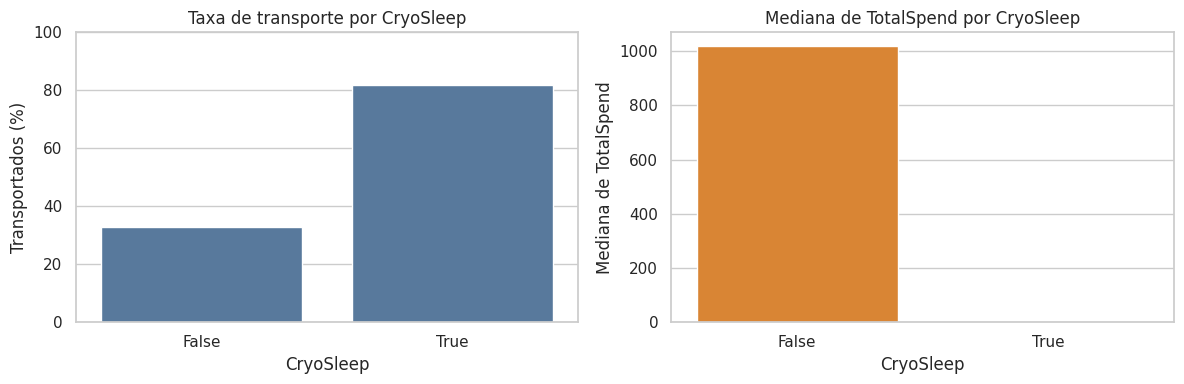

In [ ]:
# Relação entre CryoSleep, TotalSpend, gasto positivo conhecido e Transported
cryo_summary = (
    eda.groupby("CryoSleep", dropna=False)
    .agg(
        qtd_passageiros=(target, "size"),
        taxa_transporte=(target, "mean"),
        mediana_total_spend=("TotalSpend", "median"),
        media_total_spend=("TotalSpend", "mean"),
        pct_com_gasto=("SpentSomething", "mean"),
        pct_com_gasto_ausente=("HasMissingSpend", "mean"),
    )
    .reset_index()
)

for col in ["taxa_transporte", "pct_com_gasto", "pct_com_gasto_ausente"]:
    cryo_summary[col] = (cryo_summary[col] * 100).round(2)

cryo_summary[["mediana_total_spend", "media_total_spend"]] = cryo_summary[
    ["mediana_total_spend", "media_total_spend"]
].round(2)

print("Resumo por CryoSleep")
display(cryo_summary)

print("Resumo por CryoSleep e Transported")
cryo_target_summary = (
    eda.groupby(["CryoSleep", target], dropna=False)
    .agg(
        qtd_passageiros=(target, "size"),
        mediana_total_spend=("TotalSpend", "median"),
        pct_com_gasto=("SpentSomething", "mean"),
    )
    .reset_index()
)
cryo_target_summary["pct_com_gasto"] = (cryo_target_summary["pct_com_gasto"] * 100).round(2)
display(cryo_target_summary)

plot_cryo_summary = cryo_summary.copy()
plot_cryo_summary["CryoSleep"] = plot_cryo_summary["CryoSleep"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=plot_cryo_summary, x="CryoSleep", y="taxa_transporte", ax=axes[0], color="#4C78A8")
axes[0].set_title("Taxa de transporte por CryoSleep")
axes[0].set_ylabel("Transportados (%)")
axes[0].set_xlabel("CryoSleep")
axes[0].set_ylim(0, 100)

sns.barplot(data=plot_cryo_summary, x="CryoSleep", y="mediana_total_spend", ax=axes[1], color="#F58518")
axes[1].set_title("Mediana de TotalSpend por CryoSleep")
axes[1].set_ylabel("Mediana de TotalSpend")
axes[1].set_xlabel("CryoSleep")

plt.tight_layout()
plt.show()


## Relações lógicas entre PassengerGroup, FamilyName e HomePlanet

`PassengerGroup` vem do prefixo de `PassengerId`, enquanto `FamilyName` vem do sobrenome em `Name`. Esses atributos podem capturar relações familiares ou de viagem em grupo. Aqui avaliamos cardinalidade, tamanho dos grupos e o quanto esses grupos se alinham com `HomePlanet`.


Distribuição dos tamanhos de PassengerGroup


,qtd_grupos,qtd_passageiros,taxa_transporte_pct
PassengerGroupSize,,,
1,4805,4805,45.24
2,841,1682,53.80
3,340,1020,59.31
4,103,412,64.08
5,53,265,59.25
6,29,174,61.49
7,33,231,54.11
8,13,104,39.42


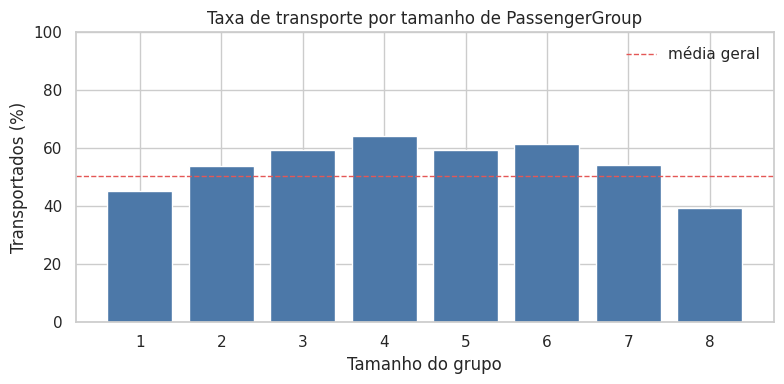

In [ ]:
# Tamanho dos grupos de passageiros e taxa de transporte por tamanho
eda["PassengerGroupSize"] = eda.groupby("PassengerGroup")["PassengerGroup"].transform("size")

passenger_group_summary = (
    eda.groupby("PassengerGroupSize")
    .agg(
        qtd_grupos=("PassengerGroup", "nunique"),
        qtd_passageiros=("PassengerGroup", "size"),
        taxa_transporte=(target, "mean"),
    )
    .sort_index()
)
passenger_group_summary["taxa_transporte_pct"] = (passenger_group_summary["taxa_transporte"] * 100).round(2)
passenger_group_summary = passenger_group_summary.drop(columns="taxa_transporte")

print("Distribuição dos tamanhos de PassengerGroup")
display(passenger_group_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(passenger_group_summary.index.astype(str), passenger_group_summary["taxa_transporte_pct"], color="#4C78A8")
ax.axhline(eda[target].mean() * 100, color="#E45756", linestyle="--", linewidth=1, label="média geral")
ax.set_title("Taxa de transporte por tamanho de PassengerGroup")
ax.set_xlabel("Tamanho do grupo")
ax.set_ylabel("Transportados (%)")
ax.set_ylim(0, 100)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
# Cardinalidade e associação entre grupo, sobrenome e HomePlanet
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency = pd.crosstab(x, y, dropna=False)
    chi2 = chi2_contingency(contingency, correction=False)[0]
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    denominator = n * min(r - 1, k - 1)
    if denominator == 0:
        return np.nan
    return np.sqrt(chi2 / denominator)

association_rows = []
for col in ["PassengerGroup", "FamilyName"]:
    homeplanet_counts = eda.groupby(col, dropna=False)["HomePlanet"].nunique(dropna=False)
    mixed = homeplanet_counts[homeplanet_counts > 1]
    association_rows.append(
        {
            "atributo": col,
            "cardinalidade": eda[col].nunique(dropna=True),
            "grupos_com_mais_de_um_homeplanet": mixed.size,
            "pct_grupos_mistos": mixed.size / homeplanet_counts.size * 100,
            "cramers_v_com_homeplanet": cramers_v(eda[col], eda["HomePlanet"]),
        }
    )

association_summary = pd.DataFrame(association_rows)
association_summary["pct_grupos_mistos"] = association_summary["pct_grupos_mistos"].round(2)
association_summary["cramers_v_com_homeplanet"] = association_summary["cramers_v_com_homeplanet"].round(4)

print("Associação entre PassengerGroup/FamilyName e HomePlanet")
display(association_summary)

family_summary = (
    eda.groupby("FamilyName", dropna=False)
    .agg(
        qtd_passageiros=(target, "size"),
        qtd_homeplanets=("HomePlanet", lambda values: values.nunique(dropna=False)),
        homeplanet_mais_frequente=("HomePlanet", lambda values: values.dropna().mode().iloc[0] if not values.dropna().mode().empty else np.nan),
        taxa_transporte=(target, "mean"),
    )
    .sort_values("qtd_passageiros", ascending=False)
)
family_summary["taxa_transporte_pct"] = (family_summary["taxa_transporte"] * 100).round(2)
family_summary = family_summary.drop(columns="taxa_transporte")

print("Sobrenomes mais frequentes")
display(family_summary.head(15))

print("Sobrenomes com pelo menos 5 passageiros e maiores taxas de transporte")
display(family_summary[family_summary["qtd_passageiros"] >= 5].sort_values("taxa_transporte_pct", ascending=False).head(15))


Associação entre PassengerGroup/FamilyName e HomePlanet


,atributo,cardinalidade,grupos_com_mais_de_um_homeplanet,pct_grupos_mistos,cramers_v_com_homeplanet
0,PassengerGroup,6217,89,1.43,0.9478
1,FamilyName,2217,182,8.21,0.8476


Sobrenomes mais frequentes


,qtd_passageiros,qtd_homeplanets,homeplanet_mais_frequente,taxa_transporte_pct
FamilyName,,,,
NaN,200,4,Earth,50.50
Casonston,18,1,Earth,38.89
Oneiles,16,1,Earth,37.50
Litthews,15,1,Earth,26.67
Domington,15,1,Earth,93.33
Fulloydez,14,1,Earth,42.86
Garnes,14,1,Earth,35.71
Cartez,14,1,Earth,50.00
Browlerson,14,1,Earth,64.29


Sobrenomes com pelo menos 5 passageiros e maiores taxas de transporte


,qtd_passageiros,qtd_homeplanets,homeplanet_mais_frequente,taxa_transporte_pct
FamilyName,,,,
Prie,6,1,Mars,100.0
Diateous,6,1,Europa,100.0
Drelcate,5,2,Europa,100.0
Connon,6,1,Earth,100.0
Carté,5,1,Mars,100.0
Holatirint,5,1,Europa,100.0
Ametic,6,1,Europa,100.0
Reenon,5,1,Earth,100.0
Stioutody,5,1,Europa,100.0


## Avaliação de discretização do atributo idade

A idade é numérica, mas pode ter faixas com comportamento diferente em relação ao alvo. Vamos olhar uma discretização interpretável e, em seguida, testar vários limiares binários para ver onde uma árvore tenderia a separar melhor as classes pelo critério de impureza de Gini.


Taxa de transporte por faixa etária candidata


,qtd_passageiros,idade_mediana,taxa_transporte_pct
AgeGroupCandidate,,,
0-4,466,1.0,76.82
5-12,340,8.0,60.59
13-17,739,15.0,55.35
18-25,2351,21.0,45.81
26-35,2105,30.0,48.31
36-50,1776,41.0,48.65
51-65,653,56.0,48.55
66+,84,70.0,47.62


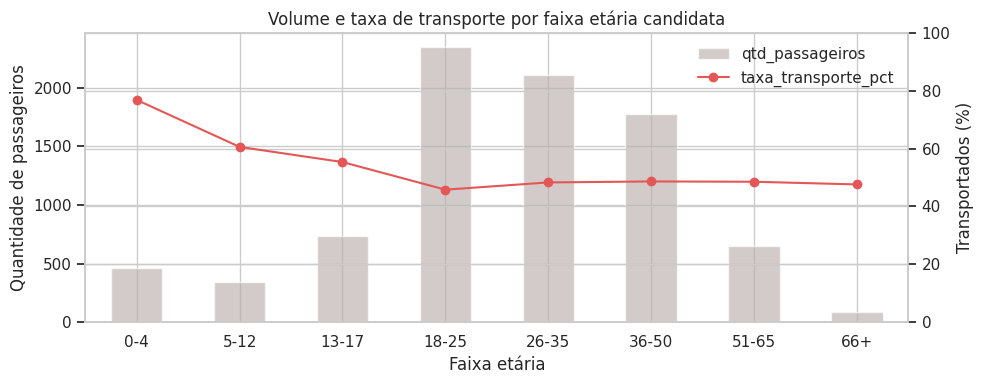

In [ ]:
# Discretização candidata de idade e taxa de transporte por faixa
age_bins = [0, 4, 12, 17, 25, 35, 50, 65, np.inf]
age_labels = ["0-4", "5-12", "13-17", "18-25", "26-35", "36-50", "51-65", "66+"]

eda["AgeGroupCandidate"] = pd.cut(
    eda["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
)

age_group_summary = (
    eda.groupby("AgeGroupCandidate", observed=True)
    .agg(
        qtd_passageiros=(target, "size"),
        taxa_transporte=(target, "mean"),
        idade_mediana=("Age", "median"),
    )
)
age_group_summary["taxa_transporte_pct"] = (age_group_summary["taxa_transporte"] * 100).round(2)
age_group_summary = age_group_summary.drop(columns="taxa_transporte")

print("Taxa de transporte por faixa etária candidata")
display(age_group_summary)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

age_group_summary["qtd_passageiros"].plot(kind="bar", ax=ax1, color="#BAB0AC", alpha=0.65, label="qtd_passageiros")
age_group_summary["taxa_transporte_pct"].plot(kind="line", ax=ax2, color="#E45756", marker="o", label="taxa_transporte_pct")

ax1.set_title("Volume e taxa de transporte por faixa etária candidata")
ax1.set_xlabel("Faixa etária")
ax1.set_ylabel("Quantidade de passageiros")
ax2.set_ylabel("Transportados (%)")
ax2.set_ylim(0, 100)
ax1.tick_params(axis="x", rotation=0)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


### Discretização binária de idade via critério de Gini

Para investigar se a idade poderia ser representada por um único corte binário, foram avaliados todos os limiares inteiros possíveis da variável `Age`.

Para cada limiar (x), os registros foram divididos em dois grupos:

* `Age <= x`
* `Age > x`

Em seguida, foi calculada a impureza de Gini ponderada dos dois grupos. O objetivo foi identificar o limiar que produz a maior separação entre passageiros transportados e não transportados.

O melhor resultado foi obtido para:

| Métrica                      | Valor     |
| ---------------------------- | --------- |
| Limiar                       | 4 anos    |
| Gini ponderado               | 0,492     |
| Taxa de transporte (Age ≤ 4) | 76,8%     |
| Taxa de transporte (Age > 4) | 48,8%     |
| Diferença absoluta           | 28,0 p.p. |
| Registros (Age ≤ 4)          | 466       |
| Registros (Age > 4)          | 8048      |

O resultado indica que crianças com até 4 anos apresentam comportamento substancialmente diferente do restante da população, com uma taxa de transporte aproximadamente 28 pontos percentuais superior.

Além disso, o mesmo limiar que minimiza a impureza de Gini também maximiza a diferença observada entre as taxas dos dois grupos, reforçando a relevância desse ponto de corte.

Esse padrão sugere que a variável idade possui um efeito não linear, sendo mais informativo distinguir crianças muito pequenas do restante da população do que utilizar apenas a idade contínua de forma isolada.


Melhor limiar binário de idade pelo critério de Gini


,valor
threshold,4.000
weighted_gini,0.492
left_rate_pct,76.824
right_rate_pct,48.832
rate_diff_pct,27.992
left_count,466.000
right_count,8048.000


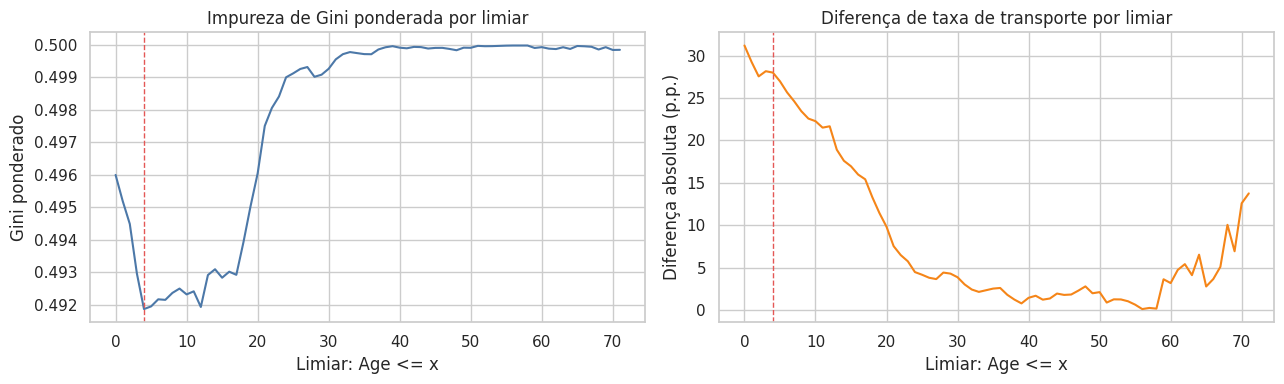

In [ ]:
# Avaliação de limiares binários para discretização de Age
def gini_impurity(values):
    p = values.mean()
    return 1 - p**2 - (1 - p)**2

age_threshold_data = eda[["Age", target]].dropna().copy()
age_threshold_data[target] = age_threshold_data[target].astype(int)

threshold_rows = []
min_age = int(np.floor(age_threshold_data["Age"].min()))
max_age = int(np.ceil(age_threshold_data["Age"].max()))

for threshold in range(min_age, max_age):
    left = age_threshold_data.loc[age_threshold_data["Age"] <= threshold, target]
    right = age_threshold_data.loc[age_threshold_data["Age"] > threshold, target]

    if len(left) < 30 or len(right) < 30:
        continue

    weighted_gini = (len(left) * gini_impurity(left) + len(right) * gini_impurity(right)) / len(age_threshold_data)
    threshold_rows.append(
        {
            "threshold": threshold,
            "weighted_gini": weighted_gini,
            "left_rate_pct": left.mean() * 100,
            "right_rate_pct": right.mean() * 100,
            "rate_diff_pct": abs(left.mean() - right.mean()) * 100,
            "left_count": len(left),
            "right_count": len(right),
        }
    )

age_threshold_eval = pd.DataFrame(threshold_rows)
best_age_threshold = age_threshold_eval.sort_values("weighted_gini").iloc[0]

print("Melhor limiar binário de idade pelo critério de Gini")
display(best_age_threshold.to_frame("valor").round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(age_threshold_eval["threshold"], age_threshold_eval["weighted_gini"], color="#4C78A8")
axes[0].axvline(best_age_threshold["threshold"], color="#E45756", linestyle="--", linewidth=1)
axes[0].set_title("Impureza de Gini ponderada por limiar")
axes[0].set_xlabel("Limiar: Age <= x")
axes[0].set_ylabel("Gini ponderado")

axes[1].plot(age_threshold_eval["threshold"], age_threshold_eval["rate_diff_pct"], color="#F58518")
axes[1].axvline(best_age_threshold["threshold"], color="#E45756", linestyle="--", linewidth=1)
axes[1].set_title("Diferença de taxa de transporte por limiar")
axes[1].set_xlabel("Limiar: Age <= x")
axes[1].set_ylabel("Diferença absoluta (p.p.)")

plt.tight_layout()
plt.show()


## Outras relações relevantes

Leitura conjunta de `CabinDeck` e `CabinSide`. Essa análise ajuda a decidir se faz sentido preservar essas duas variáveis categóricas no pré-processamento.


Taxa de transporte (%) por CabinDeck e CabinSide


CabinSide,P,S,NaN
CabinDeck,,,
A,43.59,54.68,NaN
B,67.42,78.40,NaN
C,58.06,76.35,NaN
D,40.32,46.52,NaN
E,34.27,37.14,NaN
F,41.10,47.05,NaN
G,44.83,58.38,NaN
T,25.00,0.00,NaN
NaN,NaN,NaN,50.25


Contagem de passageiros por CabinDeck e CabinSide


CabinSide,P,S,NaN
CabinDeck,,,
A,117.0,139.0,NaN
B,353.0,426.0,NaN
C,341.0,406.0,NaN
D,248.0,230.0,NaN
E,429.0,447.0,NaN
F,1438.0,1356.0,NaN
G,1276.0,1283.0,NaN
T,4.0,1.0,NaN
NaN,NaN,NaN,199.0


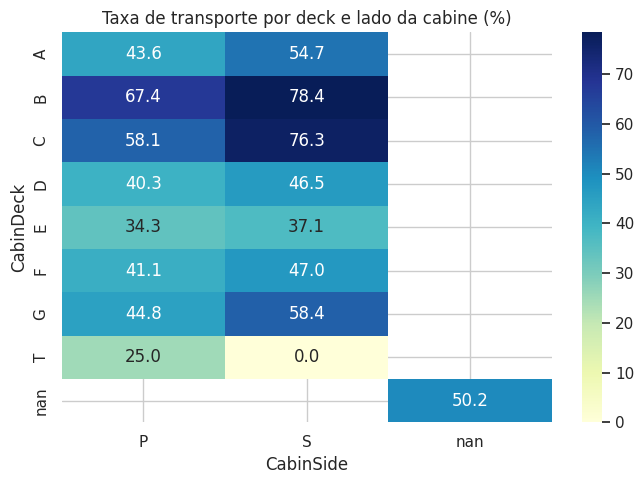

In [ ]:
# Relação conjunta entre CabinDeck, CabinSide e Transported
cabin_pair_rate = eda.groupby(["CabinDeck", "CabinSide"], dropna=False)[target].mean().unstack().mul(100).round(2)
cabin_pair_count = eda.groupby(["CabinDeck", "CabinSide"], dropna=False)[target].size().unstack()

print("Taxa de transporte (%) por CabinDeck e CabinSide")
display(cabin_pair_rate)

print("Contagem de passageiros por CabinDeck e CabinSide")
display(cabin_pair_count)

plot_cabin_pair_rate = cabin_pair_rate.copy()
plot_cabin_pair_rate.index = plot_cabin_pair_rate.index.astype(str)
plot_cabin_pair_rate.columns = plot_cabin_pair_rate.columns.astype(str)

plt.figure(figsize=(7, 5))
sns.heatmap(plot_cabin_pair_rate, cmap="YlGnBu", annot=True, fmt=".1f")
plt.title("Taxa de transporte por deck e lado da cabine (%)")
plt.xlabel("CabinSide")
plt.ylabel("CabinDeck")
plt.tight_layout()
plt.show()


## Síntese da EDA

A partir dessa exploração reorganizada, os principais aprendizados são:

- O conjunto de treino tem 8693 registros e o alvo `Transported` está praticamente balanceado.
- Os valores ausentes são baixos, em torno de 2% por atributo, então a imputação deve ser importante, mas não domina o problema.
- `CryoSleep`, `HomePlanet`, `Destination`, `CabinDeck` e `CabinSide` mostram diferenças claras de taxa de transporte entre categorias.
- As colunas de gasto têm muitos zeros. `TotalSpend` é uma boa variável agregada para simplificar o pré-processamento, embora os gastos individuais ainda carreguem nuances diferentes.
- `CryoSleep=True` se conecta fortemente a `TotalSpend=0` e a uma taxa de transporte muito maior.
- `PassengerGroup` e `FamilyName` têm alta cardinalidade e se relacionam com `HomePlanet`; eles podem ajudar o modelo, mas pedem cuidado com overfitting.
- A idade sugere uma separação inicial forte em crianças pequenas, com limiares baixos aparecendo como bons candidatos de discretização.
- A relação conjunta entre `CabinDeck` e `CabinSide` reforça a decisão de manter ambas como variáveis categóricas no pré-processamento.


# Predição de Sobrevivente: Spaceship Titanic

Este notebook concentra a parte de modelagem do projeto. A análise exploratória completa fica em `notebooks/eda.ipynb`; aqui usamos as conclusões dela para preparar os dados, treinar modelos e comparar os experimentos.

A nomenclatura dos experimentos será:
- **Caminho A**: Árvore de Decisão.
- **Caminho B**: Floresta Aleatória.
- **Caminho C**: Naive Bayes Gaussiano.

Cada experimento salva os mesmos tipos de artefatos: modelo treinado em `models/`, histórico e métricas em `reports/`, e dados/figura da curva ROC em `reports/figures/`.


## Setup do ambiente

Nesta etapa carregamos as bibliotecas, localizamos a raiz do projeto por meio de `src.roots` e criamos os diretórios de artefatos. Usar um módulo central para caminhos evita misturar diretórios do projeto com a nomenclatura dos experimentos Caminho A, Caminho B e próximos caminhos.


In [ ]:
# Bibliotecas padrão
from datetime import datetime
from pathlib import Path
import sys
from time import perf_counter
import json

# Manipulação de dados e visualização
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Persistência dos modelos treinados
from joblib import dump

# Pré-processamento, pipelines e modelos
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
import optuna

# Estilo consistente para tabelas e gráficos do notebook.
sns.set_theme(style="whitegrid")

# Permite executar o notebook a partir da raiz do projeto ou da pasta notebooks/.
PROJECT_ROOT_HINT = Path.cwd()
if not (PROJECT_ROOT_HINT / "src").exists():
    PROJECT_ROOT_HINT = PROJECT_ROOT_HINT.parent

if str(PROJECT_ROOT_HINT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT_HINT))

from src.roots import (  # noqa: E402
    FIGURES_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    TEST_DATA_PATH,
    TRAIN_DATA_PATH,
    create_required_directories,
)

create_required_directories()

print(f"Treino: {TRAIN_DATA_PATH}")
print(f"Teste: {TEST_DATA_PATH}")
print(f"Modelos serão salvos em: {MODELS_DIR}")
print(f"Relatórios serão salvos em: {REPORTS_DIR}")


Treino: /home/gabrafo/Projetos/MineracaoDeDados/data/train.csv
Teste: /home/gabrafo/Projetos/MineracaoDeDados/data/test.csv
Modelos serão salvos em: /home/gabrafo/Projetos/MineracaoDeDados/models
Relatórios serão salvos em: /home/gabrafo/Projetos/MineracaoDeDados/reports


A próxima célula carrega os arquivos de treino e teste. O conjunto de treino contém a variável alvo `Transported`; o conjunto de teste não possui rótulos e fica disponível para inferências futuras com os modelos salvos.


In [ ]:
# Carrega os dados brutos exatamente como foram fornecidos na competição.
train = pd.read_csv(TRAIN_DATA_PATH)
test = pd.read_csv(TEST_DATA_PATH)

target = "Transported"

print("Dimensões dos dados carregados")
display(
    pd.DataFrame(
        {
            "dataset": ["train", "test"],
            "linhas": [train.shape[0], test.shape[0]],
            "colunas": [train.shape[1], test.shape[1]],
        }
    )
)

print("Primeiras linhas do conjunto de treino")
display(train.head())


Dimensões dos dados carregados


,dataset,linhas,colunas
0,train,8693,14
1,test,4277,13


Primeiras linhas do conjunto de treino


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Pré-processamento

O pré-processamento transforma os dados brutos em uma matriz numérica adequada para os modelos. Essa etapa é importante porque a base mistura identificadores compostos, atributos categóricos, valores ausentes, variáveis booleanas e gastos monetários.

Vamos criar uma única pipeline de pré-processamento e reutilizá-la dentro das pipelines de cada experimento. Assim, Caminho A e Caminho B recebem exatamente as mesmas entradas transformadas, e a comparação entre os modelos fica mais justa.


A próxima célula separa `X` e `y`. Mantemos `X` ainda no formato bruto porque a engenharia de atributos fará parte da pipeline do scikit-learn. Isso garante que as transformações sejam ajustadas apenas nos folds de treino durante a validação cruzada, reduzindo risco de vazamento de dados.


In [ ]:
# X preserva as colunas originais; a pipeline será responsável por derivar e descartar colunas.
X = train.drop(columns=[target])
y = train[target].astype(int)

print("Distribuição da variável alvo")
display(
    y.value_counts(normalize=True)
    .rename_axis("Transported")
    .reset_index(name="proporcao")
    .assign(proporcao=lambda df: df["proporcao"].round(4))
)


Distribuição da variável alvo


,Transported,proporcao
0,1,0.5036
1,0,0.4964


### Engenharia de atributos base

A EDA indicou que algumas colunas precisam ser abertas antes da modelagem:
- `PassengerId` contém o grupo de viagem e o número do passageiro dentro do grupo.
- `Cabin` contém convés, número e lado da cabine.
- `Name` permite extrair o sobrenome, útil para imputar `HomePlanet`.
- As cinco colunas de gastos continuam no modelo; o agregado `TotalSpend` será criado depois da imputação dos gastos individuais.

A próxima célula cria um transformador do scikit-learn para aplicar essas regras do mesmo modo em treino, validação, teste e inferências futuras.


In [ ]:
# Colunas de gastos usadas para criar TotalSpend no pré-processamento de modelagem.
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]


class SpaceshipFeatureBuilder(BaseEstimator, TransformerMixin):
    """Cria atributos derivados a partir das colunas compostas do Spaceship Titanic."""

    def fit(self, X, y=None):
        return self

    def _split_column(self, series, separator, expected_parts):
        # str.split preserva np.nan e evita o pd.NA do dtype string, que causa erro no SimpleImputer.
        parts = series.str.split(separator, expand=True)
        for col_idx in range(expected_parts):
            if col_idx not in parts.columns:
                parts[col_idx] = np.nan
        return parts

    def transform(self, X):
        out = X.copy()

        # PassengerId tem formato gggg_pp: grupo de viagem e número no grupo.
        if "PassengerId" in out.columns:
            passenger_parts = self._split_column(out["PassengerId"], "_", expected_parts=2)
            out["PassengerGroup"] = passenger_parts[0]
            out["PassengerNum"] = pd.to_numeric(passenger_parts[1], errors="coerce")

        # Cabin tem formato deck/num/side: convés, número e lado da cabine.
        if "Cabin" in out.columns:
            cabin_parts = self._split_column(out["Cabin"], "/", expected_parts=3)
            out["CabinDeck"] = cabin_parts[0]
            out["CabinNum"] = pd.to_numeric(cabin_parts[1], errors="coerce")
            out["CabinSide"] = cabin_parts[2]

        # O sobrenome ajuda a recuperar HomePlanet quando membros da família compartilham origem.
        if "Name" in out.columns:
            out["FamilyName"] = out["Name"].str.strip().str.rsplit(" ", n=1).str[-1]

        # Removemos identificadores brutos e componentes menos úteis; mantemos os gastos individuais.
        cols_to_drop = [
            "PassengerId",
            "Cabin",
            "Name",
            "PassengerNum",
            "CabinNum",
        ]
        out = out.drop(columns=cols_to_drop, errors="ignore")

        # Normaliza tipos categóricos para object + np.nan; isso evita o erro "boolean value of NA is ambiguous".
        categorical_like = out.select_dtypes(include=["object", "string", "category", "boolean"]).columns
        for col in categorical_like:
            out[col] = out[col].astype(object).where(out[col].notna(), np.nan)

        return out


feature_builder = SpaceshipFeatureBuilder()

feature_preview = feature_builder.fit_transform(X).head()
print("Prévia dos atributos após a engenharia base")
display(feature_preview)


Prévia dos atributos após a engenharia base


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,PassengerGroup,CabinDeck,CabinSide,FamilyName
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,B,P,Ofracculy
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,F,S,Vines
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,A,S,Susent
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,A,S,Susent
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,F,S,Santantines


### Imputação de HomePlanet por regras e moda global

`HomePlanet` tem relação com o grupo de viagem e com o sobrenome. Por isso, a primeira parte da imputação usa regras determinísticas aprendidas apenas no treino:
- se houver pessoas do mesmo `PassengerGroup` com `HomePlanet` conhecido, usamos a moda do grupo;
- se ainda faltar valor, usamos a moda do `FamilyName`.

Depois dessas regras, se algum registro continuar sem `HomePlanet`, usamos o valor mais frequente de `HomePlanet` observado no dataset de treino do fold. Essa etapa final é simples, determinística e evita introduzir uma relação ordinal artificial entre categorias como `Earth`, `Europa` e `Mars`.


In [ ]:
class HomePlanetRuleImputer(BaseEstimator, TransformerMixin):
    """Preenche HomePlanet pela moda do grupo, da família e depois do dataset."""

    def __init__(self, group_col="PassengerGroup", family_col="FamilyName", target_col="HomePlanet"):
        self.group_col = group_col
        self.family_col = family_col
        self.target_col = target_col

    @staticmethod
    def _mode_or_nan(series):
        # Em caso de empate, a ordenação deixa o resultado determinístico.
        values = series.dropna()
        if values.empty:
            return np.nan
        mode_values = values.mode()
        if mode_values.empty:
            return np.nan
        return mode_values.sort_values().iloc[0]

    def fit(self, X, y=None):
        df = X.copy()

        if self.target_col in df.columns:
            self.dataset_mode_ = self._mode_or_nan(df[self.target_col])
        else:
            self.dataset_mode_ = np.nan

        if self.group_col in df.columns and self.target_col in df.columns:
            self.group_mode_ = df.groupby(self.group_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.group_mode_ = pd.Series(dtype=object)

        if self.family_col in df.columns and self.target_col in df.columns:
            self.family_mode_ = df.groupby(self.family_col)[self.target_col].apply(self._mode_or_nan)
        else:
            self.family_mode_ = pd.Series(dtype=object)

        return self

    def transform(self, X):
        df = X.copy()
        if self.target_col not in df.columns:
            return df

        homeplanet = df[self.target_col].copy()

        # Primeiro fallback: origem mais frequente dentro do mesmo grupo de viagem.
        if self.group_col in df.columns:
            group_fill = df[self.group_col].map(self.group_mode_)
            homeplanet = homeplanet.fillna(group_fill)

        # Segundo fallback: origem mais frequente para o mesmo sobrenome.
        if self.family_col in df.columns:
            family_fill = df[self.family_col].map(self.family_mode_)
            homeplanet = homeplanet.fillna(family_fill)

        # Fallback final: origem mais frequente no dataset de treino do fold.
        if pd.notna(self.dataset_mode_):
            homeplanet = homeplanet.fillna(self.dataset_mode_)

        df[self.target_col] = homeplanet.astype(object).where(homeplanet.notna(), np.nan)
        return df


### Gastos e `TotalSpend`

`TotalSpend` só deve ser criado com os cinco gastos individuais completos. Por isso, o notebook usa uma etapa dedicada:
- linhas que já têm todos os gastos recebem `TotalSpend` pela soma direta;
- linhas com algum gasto ausente têm os gastos individuais restantes imputados por `KNNImputer`;
- depois da imputação, `TotalSpend` é recalculado com base nos gastos completos que entram no modelo.


In [ ]:
class SpendKNNImputerAndTotalSpend(BaseEstimator, TransformerMixin):
    """Imputa gastos individuais com KNN e cria TotalSpend sem somas parciais."""

    def __init__(self, spend_columns=None, total_col="TotalSpend", n_neighbors=5):
        self.spend_columns = spend_columns
        self.total_col = total_col
        self.n_neighbors = n_neighbors

    def _spend_frame(self, df):
        return df.reindex(columns=self.spend_columns_).apply(pd.to_numeric, errors="coerce")

    def fit(self, X, y=None):
        df = X.copy()
        self.spend_columns_ = list(self.spend_columns or [])
        self.spend_imputer_ = None

        if self.spend_columns_:
            spend_frame = self._spend_frame(df)
            self.spend_imputer_ = KNNImputer(
                n_neighbors=self.n_neighbors,
                keep_empty_features=True,
            )
            self.spend_imputer_.fit(spend_frame)

        return self

    def transform(self, X):
        df = X.copy()
        if not self.spend_columns_:
            return df

        spend_frame = self._spend_frame(df)
        complete_rows = spend_frame.notna().all(axis=1)

        if (~complete_rows).any() and self.spend_imputer_ is not None:
            imputed_values = self.spend_imputer_.transform(spend_frame)
            spend_complete = pd.DataFrame(
                imputed_values,
                columns=self.spend_columns_,
                index=df.index,
            )
        else:
            spend_complete = spend_frame

        df[self.spend_columns_] = spend_complete
        df[self.total_col] = spend_complete.sum(axis=1)
        return df


### Pipeline de pré-processamento

A próxima célula monta a pipeline compartilhada. Ela aplica a engenharia de atributos, imputa `HomePlanet`, trata os gastos antes de criar `TotalSpend`, transforma variáveis numéricas, binárias e categóricas, e entrega uma matriz pronta para o classificador.

As escolhas principais são:
- regras por grupo e família, mais moda global observada no treino, para preencher `HomePlanet`;
- `SpendKNNImputerAndTotalSpend` para imputar gastos individuais restantes e criar `TotalSpend` sem soma parcial;
- `KNNImputer` e `StandardScaler` para numéricas (`Age`, gastos individuais já imputados e `TotalSpend`);
- `OrdinalEncoder` + `KNNImputer` para binárias (`CabinSide`, `CryoSleep`, `VIP`);
- `SimpleImputer` + `OneHotEncoder` para categóricas de múltiplas classes.


In [ ]:
# Colunas esperadas depois de SpaceshipFeatureBuilder e SpendKNNImputerAndTotalSpend.
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "TotalSpend"]
binary_cols = ["CabinSide", "CryoSleep", "VIP"]
categorical_ohe = ["CabinDeck", "Destination", "HomePlanet", "PassengerGroup", "FamilyName"]


def round_binary(values):
    """Arredonda saídas do KNN para os códigos binários 0/1."""
    return np.clip(np.rint(values), 0, 1).astype(int)


numeric_pipeline = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler()),
    ]
)

binary_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OrdinalEncoder(
                categories=[["P", "S"], [False, True], [False, True]],
                handle_unknown="use_encoded_value",
                unknown_value=np.nan,
            ),
        ),
        ("imputer", KNNImputer(n_neighbors=5)),
        ("rounder", FunctionTransformer(round_binary, feature_names_out="one-to-one")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

column_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_ohe),
    ],
    remainder="drop",
)

preprocessing_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        ("homeplanet_rules", HomePlanetRuleImputer()),
        (
            "spend_total",
            SpendKNNImputerAndTotalSpend(
                spend_columns=spend_cols,
                n_neighbors=5,
            ),
        ),
        ("columns", column_preprocessor),
    ]
)

print("Pipeline de pré-processamento compartilhada")
preprocessing_pipeline


Pipeline de pré-processamento compartilhada


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,total_col,'TotalSpend'
,n_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"


Ao final do pré-processamento, temos uma etapa única e reutilizável que:
- cria atributos derivados de identificadores compostos;
- imputa gastos individuais restantes e adiciona `TotalSpend` como agregado completo;
- preenche `HomePlanet` por regras e, se necessário, pela moda global do treino;
- codifica variáveis categóricas e binárias;
- trata valores ausentes antes do treinamento.

Essa mesma pipeline será instanciada dentro das pipelines de Caminho A e Caminho B.


## Configuração comum de avaliação e artefatos

Antes dos modelos, definimos apenas utilitários pequenos e reutilizáveis: criação da pipeline completa, cálculo de métricas e salvamento padronizado dos artefatos. A execução de cada experimento ficará em uma célula própria, para deixar o fluxo de treino e avaliação mais direto.

Os arquivos salvos seguem o padrão `history_path_*_timestamp.csv`, `metrics_path_*_timestamp.csv`, `roc_path_*_timestamp.csv` e `model_path_*_timestamp.joblib`.


In [ ]:
def make_model_pipeline(estimator):
    """Cria uma pipeline completa com uma cópia limpa do pré-processamento compartilhado."""
    return Pipeline(
        steps=[
            ("preprocess", clone(preprocessing_pipeline)),
            ("model", estimator),
        ]
    )


def classification_metrics(y_true, y_pred, y_score):
    """Calcula métricas globais para um fold ou para as predições out-of-fold."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f1_class_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_class_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }


def build_artifact_files(experiment_id, timestamp=None):
    """Gera nomes de arquivos padronizados para os artefatos do experimento."""
    timestamp = timestamp or datetime.now().strftime("%Y%m%d_%H%M%S")
    experiment_slug = experiment_id.lower().replace(" ", "_")

    return {
        "timestamp": timestamp,
        "model": MODELS_DIR / f"model_{experiment_slug}_{timestamp}.joblib",
        "history": REPORTS_DIR / f"history_{experiment_slug}_{timestamp}.csv",
        "metrics": REPORTS_DIR / f"metrics_{experiment_slug}_{timestamp}.csv",
        "predictions": REPORTS_DIR / f"predictions_{experiment_slug}_{timestamp}.csv",
        "roc_csv": FIGURES_DIR / f"roc_{experiment_slug}_{timestamp}.csv",
        "roc_png": FIGURES_DIR / f"roc_{experiment_slug}_{timestamp}.png",
        "params": MODELS_DIR / f"params_{experiment_slug}.json",
    }


def build_prediction_frame(fitted_pipeline, test_df):
    """Gera o CSV de submissão com as predições do modelo para o conjunto de teste."""
    predictions = fitted_pipeline.predict(test_df).astype(bool)
    return pd.DataFrame(
        {
            "PassengerId": test_df["PassengerId"],
            target: predictions,
        }
    )


def save_experiment_artifacts(
    fitted_pipeline,
    history_df,
    metrics_df,
    roc_df,
    roc_fig,
    artifact_files,
    predictions_df=None,
    best_params=None,
):
    """Salva modelo, parâmetros, histórico, métricas, curva ROC e predições."""
    dump(fitted_pipeline, artifact_files["model"])
    history_df.to_csv(artifact_files["history"], index=False)
    metrics_df.to_csv(artifact_files["metrics"], index=False)
    roc_df.to_csv(artifact_files["roc_csv"], index=False)
    roc_fig.savefig(artifact_files["roc_png"], dpi=160, bbox_inches="tight")
    if predictions_df is not None:
        predictions_df.to_csv(artifact_files["predictions"], index=False)
    
    if best_params:
        with open(artifact_files["params"], "w") as f:
            json.dump(best_params, f, indent=4)


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metric_cols = ["accuracy", "precision", "recall", "f1", "f1_class_0", "f1_class_1", "roc_auc"]

### Breve diferenciação: qual a diferença da curva ROC out-of-fold vs a curva ROC construída a partir de holdout?

Na ROC/AUC out-of-fold (OOF), cada amostra recebe o score do fold em que ela ficou como validação. Assim, a curva é construída com predições que vieram de modelos que não viram aqueles registros no treino, e os folds são combinados em uma única avaliação.

Na ROC/AUC de holdout, existe um único conjunto separado antes do treino. O modelo é ajustado no treino e avaliado só nesse holdout. É mais simples e rápido, mas a métrica fica mais sensível à divisão escolhida.

Em geral, a ROC/AUC OOF tende a ser mais estável e representativa; a de holdout é útil para uma checagem rápida ou quando você precisa de uma divisão fixa. Usaremos a ROC/AUC OOF sempre.


### Otimização de Hiperparâmetros com Optuna

Neste projeto, usamos o **Optuna** para automatizar essa escolha. O Optuna é uma biblioteca de otimização de hiperparâmetros. Em vez de testar combinações manualmente, definimos quais hiperparâmetros podem variar e qual métrica queremos melhorar. A partir disso, o Optuna executa várias tentativas, compara os resultados e identifica a combinação que apresentou melhor desempenho.

A métrica usada para orientar a busca foi a **ROC AUC** em validação cruzada estratificada. Essa métrica avalia a capacidade do modelo de separar corretamente passageiros transportados e não transportados considerando diferentes limiares de decisão. Como o objetivo é maximizar essa separação, o Optuna procura as configurações que produzem maior ROC AUC média nos folds de validação.

Cada caminho de modelagem teve seu próprio conjunto de hiperparâmetros otimizados:

| Caminho | Modelo | Hiperparâmetros otimizados |
|---|---|---|
| Caminho A | Árvore de Decisão | Profundidade máxima da árvore e número mínimo de amostras para dividir um nó |
| Caminho B | Floresta Aleatória | Número de árvores, número mínimo de amostras para divisão, número mínimo de amostras em folhas e quantidade de atributos considerados por divisão |
| Caminho C | Naive Bayes Gaussiano | Suavização da variância |

O Optuna não testa combinações de forma totalmente fixa, como em uma busca em grade tradicional. Ele usa estratégias de amostragem que aproveitam o histórico das tentativas anteriores. Em termos simples, depois de observar quais regiões do espaço de busca geraram bons resultados, ele passa a explorar mais combinações parecidas com aquelas. Isso torna a busca mais eficiente do que simplesmente testar valores aleatórios ou percorrer todas as combinações possíveis.

No notebook, a busca foi limitada a 30 tentativas por caminho. Esse número representa um equilíbrio entre custo computacional e qualidade da otimização. Mais tentativas poderiam encontrar resultados melhores, mas também aumentariam o tempo de execução.

Para tornar o processo mais prático e reprodutível, os melhores hiperparâmetros encontrados são salvos em arquivos JSON na pasta `models/`. Assim, quando o notebook é executado novamente, ele pode reaproveitar os valores já encontrados em vez de rodar toda a otimização outra vez. Caso esses arquivos sejam removidos, o Optuna executa uma nova busca.

No estado atual do projeto, os melhores parâmetros encontrados indicam uma árvore de decisão mais controlada, uma floresta aleatória com árvores mais suavizadas e um Naive Bayes com suavização relativamente alta. Esses ajustes ajudam a reduzir overfitting, melhorar estabilidade e tornar a comparação entre os modelos mais justa.

É importante destacar que a otimização com Optuna melhora a escolha das configurações dos modelos, mas não garante encontrar a melhor combinação possível em termos absolutos. O resultado depende do espaço de busca definido, da métrica escolhida e do número de tentativas executadas. Ainda assim, o uso do Optuna torna o processo mais sistemático do que uma escolha manual de hiperparâmetros.

Também existe uma limitação metodológica: a busca de hiperparâmetros e a avaliação final usam o mesmo conjunto de treino, ainda que com validação cruzada. Isso é adequado para comparar os caminhos dentro do projeto, mas pode produzir uma estimativa um pouco otimista do desempenho real. Para uma avaliação mais rigorosa, seria possível reservar um conjunto de holdout final ou usar nested cross-validation.

## Árvore de Decisão

Uma árvore de decisão aprende uma sequência de perguntas sobre os atributos. Em cada nó, o algoritmo escolhe uma divisão que separa melhor as classes; no final, cada folha representa uma regra de decisão e retorna uma classe provável.

A vantagem é a interpretação simples. A limitação é que árvores isoladas podem se ajustar demais ao treino quando crescem sem controle, por isso a validação cruzada é essencial para medir generalização.


### Treinamento

Caminho A usa `DecisionTreeClassifier`. A pipeline completa contém duas partes: primeiro o pré-processamento compartilhado, depois o classificador. Nesta versão mantemos os hiperparâmetros selecionados pelo Optuna, uma biblioteca de código aberto em Python voltada à otimização automática de hiperparâmetros, seu uso se deve à descoberta inteligente de valores sem depender de força bruta, tornando o procedimento mais viavel computacionalmente. Além disso, foi definido `random_state=42` para garantir reprodutibilidade.


In [ ]:
experiment_id = "path_a"
params_path = MODELS_DIR / f"params_{experiment_id}.json"

# Carrega parâmetros se o artefato existir, ou roda o Optuna
if params_path.exists():
    with open(params_path, "r") as f:
        best_params = json.load(f)
else:
    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 50)
        }
        # Instancia o modelo com os parâmetros sugeridos
        model = DecisionTreeClassifier(random_state=42, **params)
        pipeline = make_model_pipeline(model)
        
        # Avalia e retorna a métrica alvo
        return cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    best_params = study.best_params
    
    print("Melhores parâmetros encontrados pelo Optuna:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

# Constrói a pipeline final usando os melhores parâmetros (desempacotando o dicionário)
final_model = DecisionTreeClassifier(random_state=42, **best_params)
path_a_pipeline = make_model_pipeline(final_model)

print("Pipeline do caminho A")
path_a_pipeline

Pipeline do caminho A


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'


Árvore do Caminho A salva em: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/tree_path_a_20260605_092509.svg


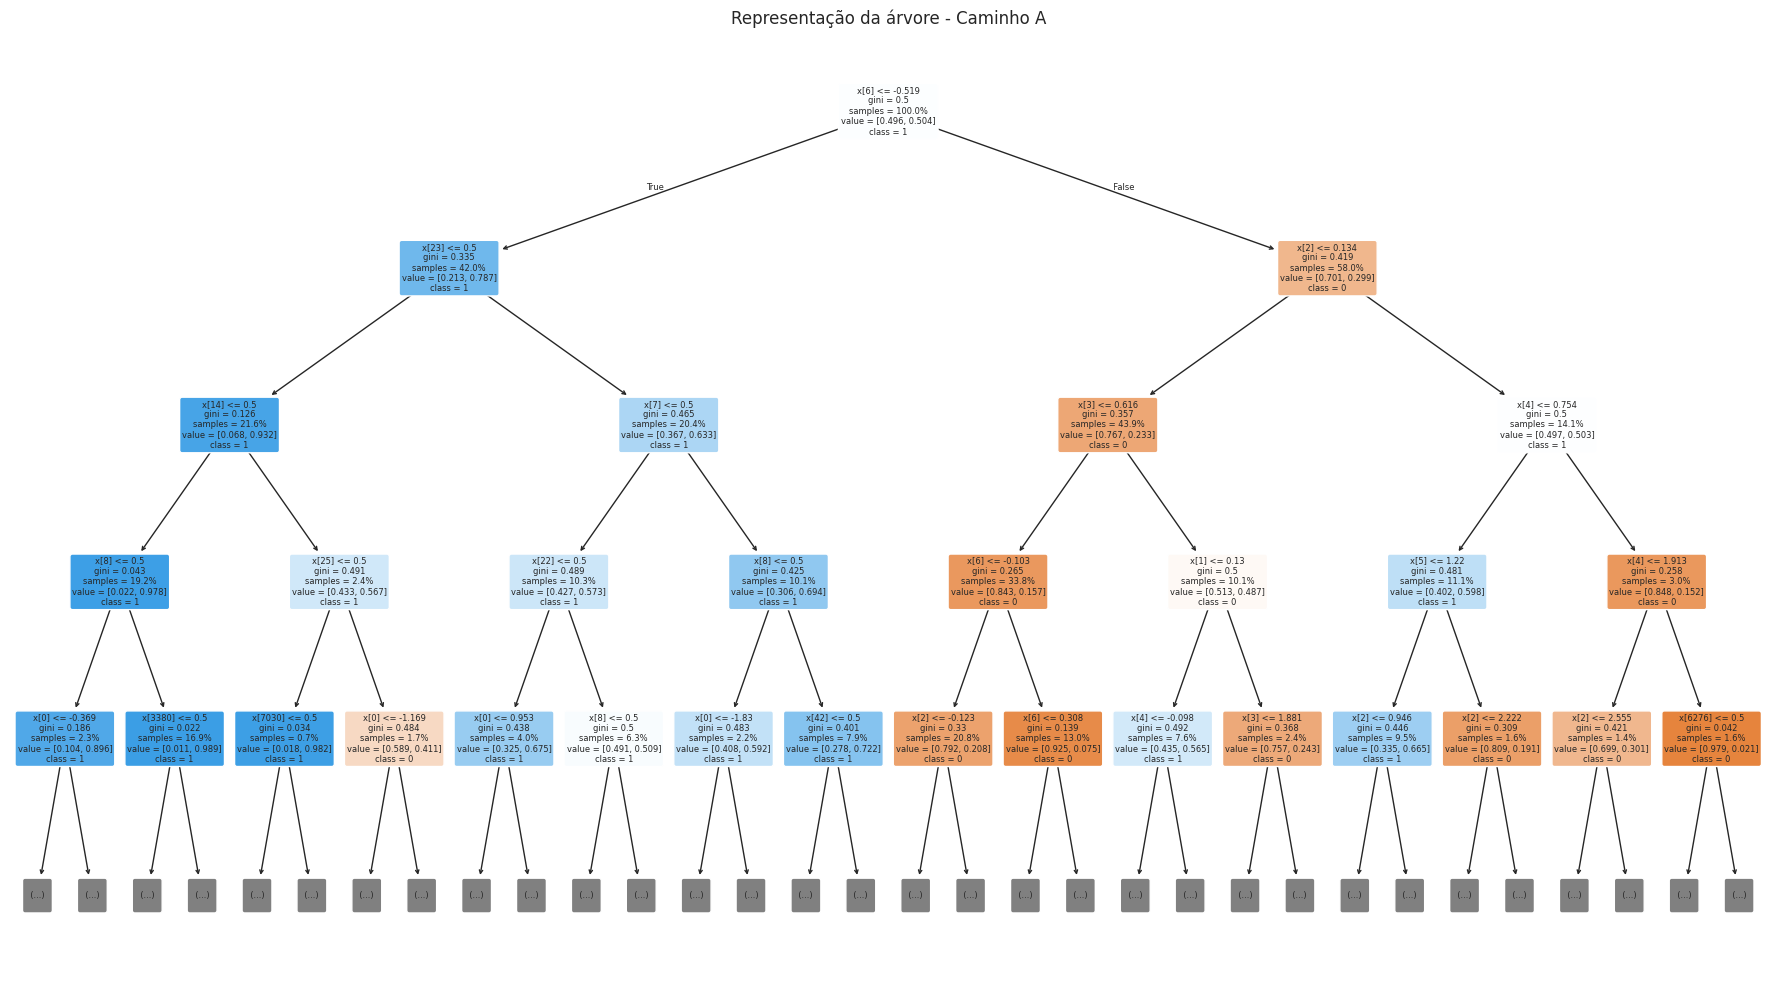

In [ ]:
path_a_viz_pipeline = clone(path_a_pipeline)
path_a_viz_pipeline.fit(X, y)

path_a_tree = path_a_viz_pipeline.named_steps["model"]

path_a_tree_fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    path_a_tree,
    max_depth=4,
    filled=True,
    rounded=True,
    proportion=True,
    class_names=["0", "1"],
    ax=ax,
    fontsize=6,
)
ax.set_title("Representação da árvore - Caminho A")
plt.tight_layout()

path_a_tree_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
path_a_tree_artifact = FIGURES_DIR / f"tree_path_a_{path_a_tree_timestamp}.svg"
path_a_tree_fig.savefig(path_a_tree_artifact, bbox_inches="tight")

print(f"Árvore do Caminho A salva em: {path_a_tree_artifact}")
plt.show()

### Avaliação

A avaliação do Caminho A usa validação cruzada estratificada com 10 folds. Em cada fold medimos acurácia, precisão, recall, F1, F1 por classe e ROC AUC. A curva ROC é construída a partir das predições out-of-fold, ou seja, cada ponto previsto vem de um modelo que não treinou naquele registro.

Ao final, treinamos novamente a pipeline em todo o conjunto de treino e salvamos modelo, histórico, métricas e ROC com o padrão de artefatos do projeto.


Artefatos salvos para Caminho A - Árvore de Decisão
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_a_20260605_092539.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_a_20260605_092539.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_a_20260605_092539.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_a_20260605_092539.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_a_20260605_092539.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_a,Caminho A - Árvore de Decisão,accuracy,0.7848,0.0204,0.7848
1,path_a,Caminho A - Árvore de Decisão,precision,0.7681,0.0171,0.7681
2,path_a,Caminho A - Árvore de Decisão,recall,0.8202,0.0292,0.8202
3,path_a,Caminho A - Árvore de Decisão,f1,0.7932,0.0211,0.7933
4,path_a,Caminho A - Árvore de Decisão,f1_class_0,0.7755,0.0200,0.7755
5,path_a,Caminho A - Árvore de Decisão,f1_class_1,0.7932,0.0211,0.7933
6,path_a,Caminho A - Árvore de Decisão,roc_auc,0.8681,0.0164,0.8674


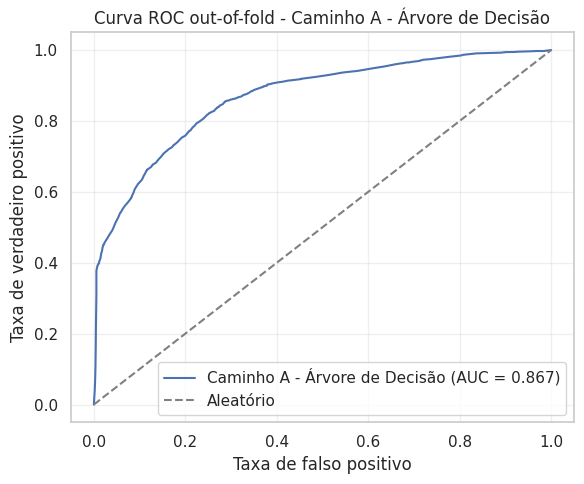

In [ ]:
# Avaliação e salvamento do Caminho A - Árvore de Decisão
experiment_id = "path_a"
experiment_label = "Caminho A - Árvore de Decisão"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_a_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_a_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_a_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_a_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_a_oof_pred.iloc[valid_idx] = fold_pred
    path_a_oof_score.iloc[valid_idx] = fold_score

    path_a_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_a_history = pd.DataFrame(path_a_history_rows)
path_a_oof_metrics = classification_metrics(
    y_cv,
    path_a_oof_pred.astype(int),
    path_a_oof_score.astype(float),
)

path_a_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_a_history[metric].mean(),
            "cv_std": path_a_history[metric].std(ddof=0),
            "out_of_fold": path_a_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_a_oof_score.astype(float))
path_a_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_a_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_a_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_a_final_pipeline = clone(path_a_pipeline)
path_a_final_pipeline.fit(X_cv, y_cv)
path_a_predictions = build_prediction_frame(path_a_final_pipeline, test)

path_a_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_a_final_pipeline,
    history_df=path_a_history,
    metrics_df=path_a_metrics,
    roc_df=path_a_roc,
    roc_fig=path_a_fig,
    artifact_files=path_a_artifacts,
    predictions_df=path_a_predictions,
    best_params=best_params,
)

path_a_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_a_final_pipeline,
    "history": path_a_history,
    "metrics": path_a_metrics,
    "roc": path_a_roc,
    "predictions": path_a_predictions,
    "artifact_files": path_a_artifacts,
    "oof_pred": path_a_oof_pred.astype(int),
    "oof_score": path_a_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "predictions", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_a_artifacts[key]}")

display(path_a_metrics.round(4))
plt.show()

## Floresta Aleatória

Uma floresta aleatória combina várias árvores de decisão treinadas com amostras e subconjuntos de atributos diferentes. Cada árvore vota em uma classe, e o conjunto tende a ser mais estável do que uma árvore única.

A vantagem principal é reduzir variância e melhorar generalização. O custo é menor interpretabilidade e mais tempo de treinamento.


### Treinamento

Caminho B usa `RandomForestClassifier` com `n_estimators=216`, ou seja, 216 árvores no conjunto. Mantemos `random_state=42` para reprodutibilidade e `n_jobs=-1` para permitir paralelização interna do modelo.

A pipeline de entrada é a mesma do Caminho A: pré-processamento compartilhado seguido do classificador.


In [ ]:
experiment_id = "path_b"
params_path = MODELS_DIR / f"params_{experiment_id}.json"

# Carrega parâmetros se o artefato existir, ou roda o Optuna
if params_path.exists():
    with open(params_path, "r") as f:
        best_params = json.load(f)
else:
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
        }
        # Instancia o modelo com os parâmetros sugeridos
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
        pipeline = make_model_pipeline(model)
        
        # Avalia e retorna a métrica alvo
        return cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    best_params = study.best_params
    print("Melhores parâmetros encontrados pelo Optuna:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

# Constrói a pipeline final usando os melhores parâmetros (desempacotando o dicionário)
final_model = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
path_b_pipeline = make_model_pipeline(final_model)

print("Pipeline do caminho B")
path_b_pipeline

Pipeline do caminho B


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'


Árvore do Caminho B salva em: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/tree_path_b_20260605_092544.svg


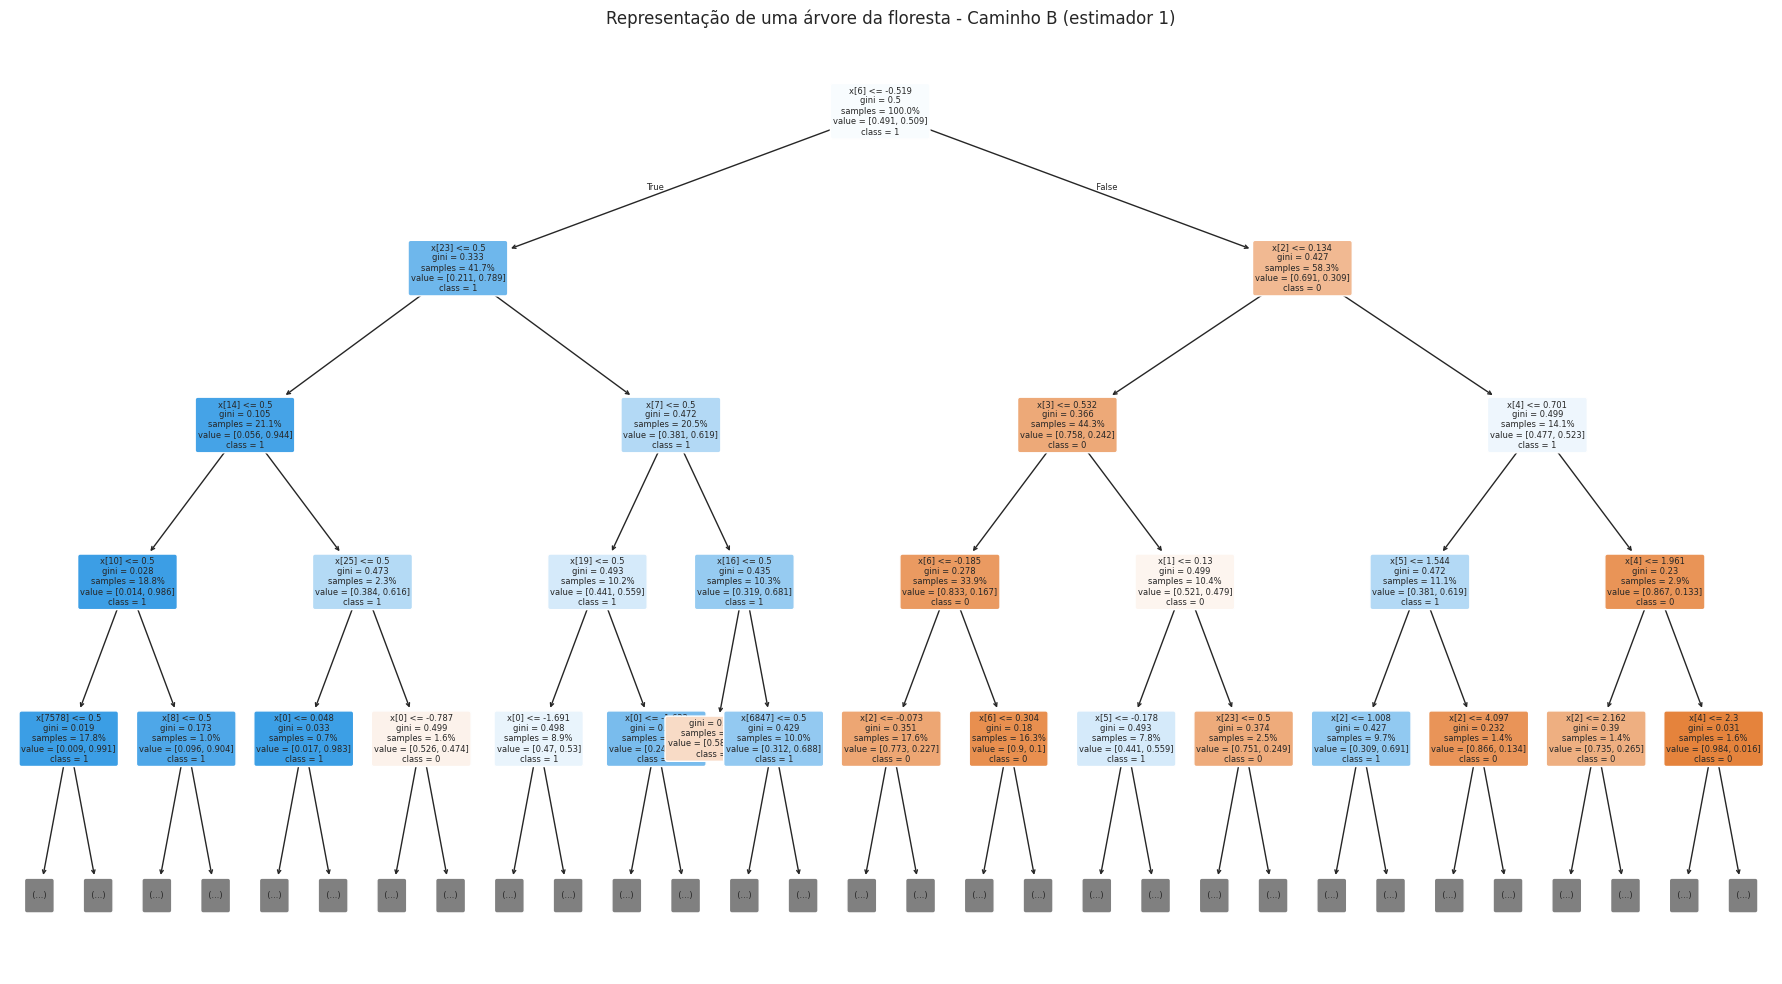

In [ ]:
path_b_viz_pipeline = clone(path_b_pipeline)
path_b_viz_pipeline.fit(X, y)

path_b_forest = path_b_viz_pipeline.named_steps["model"]
path_b_tree_index = 0
path_b_tree = path_b_forest.estimators_[path_b_tree_index]

path_b_tree_fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    path_b_tree,
    max_depth=4,
    filled=True,
    rounded=True,
    proportion=True,
    class_names=["0", "1"],
    ax=ax,
    fontsize=6,
)
ax.set_title(
    f"Representação de uma árvore da floresta - Caminho B (estimador {path_b_tree_index + 1})" # Apenas uma das 200 árvores
)
plt.tight_layout()

path_b_tree_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
path_b_tree_artifact = FIGURES_DIR / f"tree_path_b_{path_b_tree_timestamp}.svg"
path_b_tree_fig.savefig(path_b_tree_artifact, bbox_inches="tight")

print(f"Árvore do Caminho B salva em: {path_b_tree_artifact}")
plt.show()

### Avaliação

O Caminho B é avaliado com o mesmo procedimento do Caminho A. Isso mantém a comparação justa: mesmos folds, mesmas métricas, mesma forma de gerar a curva ROC out-of-fold e mesma rotina de salvamento de artefatos.


Artefatos salvos para Caminho B - Floresta Aleatória
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_b_20260605_092636.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_b_20260605_092636.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_b_20260605_092636.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_b_20260605_092636.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_b_20260605_092636.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_b,Caminho B - Floresta Aleatória,accuracy,0.7988,0.0147,0.7988
1,path_b,Caminho B - Floresta Aleatória,precision,0.8067,0.0122,0.8068
2,path_b,Caminho B - Floresta Aleatória,recall,0.7896,0.0243,0.7896
3,path_b,Caminho B - Floresta Aleatória,f1,0.7980,0.0167,0.7981
4,path_b,Caminho B - Floresta Aleatória,f1_class_0,0.7996,0.0132,0.7995
5,path_b,Caminho B - Floresta Aleatória,f1_class_1,0.7980,0.0167,0.7981
6,path_b,Caminho B - Floresta Aleatória,roc_auc,0.8869,0.0132,0.8866


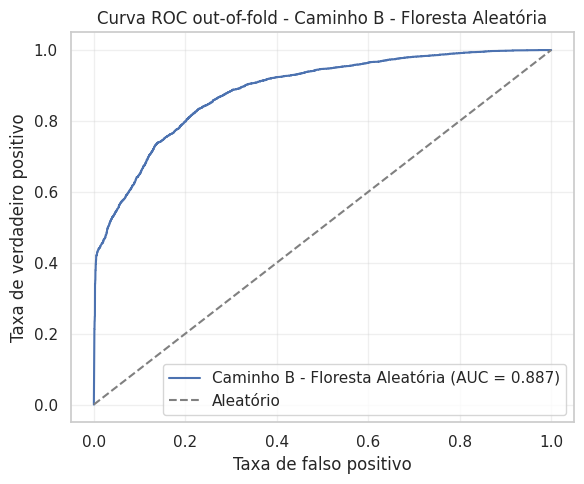

In [ ]:
# Avaliação e salvamento do Caminho B - Floresta Aleatória
experiment_id = "path_b"
experiment_label = "Caminho B - Floresta Aleatória"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_b_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_b_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_b_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_b_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_b_oof_pred.iloc[valid_idx] = fold_pred
    path_b_oof_score.iloc[valid_idx] = fold_score

    path_b_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_b_history = pd.DataFrame(path_b_history_rows)
path_b_oof_metrics = classification_metrics(
    y_cv,
    path_b_oof_pred.astype(int),
    path_b_oof_score.astype(float),
)

path_b_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_b_history[metric].mean(),
            "cv_std": path_b_history[metric].std(ddof=0),
            "out_of_fold": path_b_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_b_oof_score.astype(float))
path_b_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_b_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_b_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_b_final_pipeline = clone(path_b_pipeline)
path_b_final_pipeline.fit(X_cv, y_cv)
path_b_predictions = build_prediction_frame(path_b_final_pipeline, test)

path_b_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_b_final_pipeline,
    history_df=path_b_history,
    metrics_df=path_b_metrics,
    roc_df=path_b_roc,
    roc_fig=path_b_fig,
    artifact_files=path_b_artifacts,
    predictions_df=path_b_predictions,
    best_params=best_params,
)

path_b_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_b_final_pipeline,
    "history": path_b_history,
    "metrics": path_b_metrics,
    "roc": path_b_roc,
    "predictions": path_b_predictions,
    "artifact_files": path_b_artifacts,
    "oof_pred": path_b_oof_pred.astype(int),
    "oof_score": path_b_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "predictions", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_b_artifacts[key]}")

display(path_b_metrics.round(4))
plt.show()

## Naive Bayes Gaussiano

O Caminho C usa `GaussianNB`, um modelo probabilístico que estima, para cada classe, uma distribuição normal por atributo numérico transformado. Ele é simples, rápido e serve como um contraste útil com os modelos baseados em árvores dos Caminhos A e B.


### Pipeline de pré-processamento

A próxima célula cria uma variação mínima da pipeline original apenas para o `GaussianNB`. Mantemos a mesma engenharia de atributos, as mesmas imputações, o `StandardScaler` das variáveis numéricas e a mesma codificação das variáveis binárias e categóricas.

A diferença necessária está no `OneHotEncoder`: na pipeline compartilhada ele gera saída esparsa, adequada para economizar memória em árvore de decisão e floresta aleatória. O `GaussianNB`, porém, espera uma matriz densa para estimar médias e variâncias de cada atributo por classe. Por isso, esta versão altera somente `sparse_output=False` no one-hot e fica restrita ao Caminho C.


In [ ]:
gaussian_nb_preprocessing_pipeline = clone(preprocessing_pipeline).set_params(
    columns__cat__encoder__sparse_output=False,
)

print("Pipeline de pré-processamento alternativa para GaussianNB")
gaussian_nb_preprocessing_pipeline


Pipeline de pré-processamento alternativa para GaussianNB


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'
,spend_columns,"['RoomService', 'FoodCourt', ...]"
,total_col,'TotalSpend'
,n_neighbors,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"


### Treinamento

Caminho C usa `GaussianNB`. Diferente das árvores, ele não aprende divisões ou conjuntos de árvores: ele estima a probabilidade de cada classe a partir das distribuições dos atributos já transformados. A pipeline completa usa o pré-processamento alternativo definido acima e depois o classificador gaussiano.


In [ ]:
experiment_id = "path_c"
params_path = MODELS_DIR / f"params_{experiment_id}.json"

# Carrega parâmetros se o artefato existir, ou roda o Optuna
if params_path.exists():
    with open(params_path, "r") as f:
        best_params = json.load(f)
else:
    def objective(trial):
        params = {
            "var_smoothing": trial.suggest_float("var_smoothing", 1e-9, 1e-3, log=True)
        }
        # Instancia o modelo com os parâmetros sugeridos
        model = GaussianNB(**params)
        pipeline = Pipeline(
            steps=[
                ("preprocess", clone(gaussian_nb_preprocessing_pipeline)),
                ("model", model),
            ]
        )
        
        # Avalia e retorna a métrica alvo
        return cross_val_score(pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=30)
    best_params = study.best_params
    
    print("Melhores parâmetros encontrados pelo Optuna:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

# Constrói a pipeline final usando os melhores parâmetros (desempacotando o dicionário)
final_model = GaussianNB(**best_params)
pipeline = Pipeline(
    steps=[
        ("preprocess", clone(gaussian_nb_preprocessing_pipeline)),
        ("model", final_model),
    ]
)
path_c_pipeline = pipeline

print("Pipeline do caminho C")
path_c_pipeline

[I 2026-06-05 09:26:37,067] A new study created in memory with name: no-name-be7b7546-75a4-4770-b76f-10dfc22fdead
[I 2026-06-05 09:26:58,970] Trial 0 finished with value: 0.5244450279728359 and parameters: {'var_smoothing': 4.178560590833027e-08}. Best is trial 0 with value: 0.5244450279728359.
[I 2026-06-05 09:27:15,368] Trial 1 finished with value: 0.5714223965281666 and parameters: {'var_smoothing': 0.0005866714266737888}. Best is trial 1 with value: 0.5714223965281666.
[I 2026-06-05 09:27:26,238] Trial 2 finished with value: 0.5309418682669692 and parameters: {'var_smoothing': 4.478808212323461e-06}. Best is trial 1 with value: 0.5714223965281666.
[I 2026-06-05 09:27:37,709] Trial 3 finished with value: 0.5250729708918358 and parameters: {'var_smoothing': 3.0402226857453434e-09}. Best is trial 1 with value: 0.5714223965281666.
[I 2026-06-05 09:27:49,413] Trial 4 finished with value: 0.5245808431260343 and parameters: {'var_smoothing': 1.8773522532495835e-08}. Best is trial 1 with v

Melhores parâmetros encontrados pelo Optuna:
  var_smoothing: 0.0009815405019274585
Pipeline do caminho C


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('homeplanet_rules', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,group_col,'PassengerGroup'
,family_col,'FamilyName'
,target_col,'HomePlanet'


### Avaliação

O Caminho C é avaliado com o mesmo procedimento dos Caminhos A e B: validação cruzada estratificada com 10 folds, métricas out-of-fold, curva ROC out-of-fold e salvamento dos mesmos artefatos. Assim, a comparação no benchmarking continua justa, mudando apenas o modelo e a adaptação técnica necessária para o `GaussianNB`.


Artefatos salvos para Caminho C - Naive Bayes Gaussiano
- model: /home/gabrafo/Projetos/MineracaoDeDados/models/model_path_c_20260605_093303.joblib
- history: /home/gabrafo/Projetos/MineracaoDeDados/reports/history_path_c_20260605_093303.csv
- metrics: /home/gabrafo/Projetos/MineracaoDeDados/reports/metrics_path_c_20260605_093303.csv
- roc_csv: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_c_20260605_093303.csv
- roc_png: /home/gabrafo/Projetos/MineracaoDeDados/reports/figures/roc_path_c_20260605_093303.png


,experiment_id,experiment_label,metric,cv_mean,cv_std,out_of_fold
0,path_c,Caminho C - Naive Bayes Gaussiano,accuracy,0.5809,0.0143,0.5809
1,path_c,Caminho C - Naive Bayes Gaussiano,precision,0.5804,0.0144,0.5802
2,path_c,Caminho C - Naive Bayes Gaussiano,recall,0.6071,0.0247,0.6071
3,path_c,Caminho C - Naive Bayes Gaussiano,f1,0.5932,0.0157,0.5934
4,path_c,Caminho C - Naive Bayes Gaussiano,f1_class_0,0.5675,0.0183,0.5677
5,path_c,Caminho C - Naive Bayes Gaussiano,f1_class_1,0.5932,0.0157,0.5934
6,path_c,Caminho C - Naive Bayes Gaussiano,roc_auc,0.5878,0.0137,0.5876


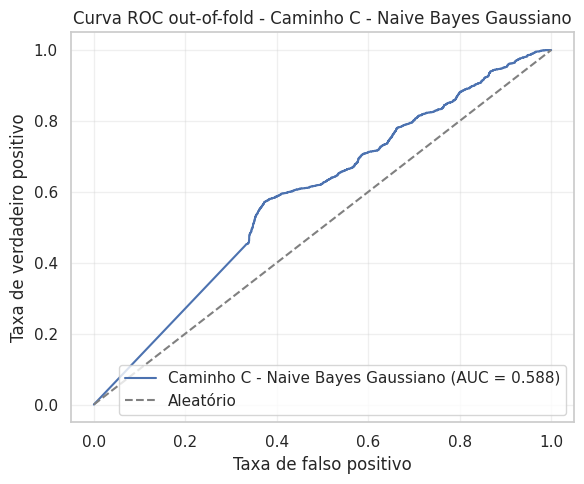

In [ ]:
# Avaliação e salvamento do Caminho C - Naive Bayes Gaussiano
experiment_id = "path_c"
experiment_label = "Caminho C - Naive Bayes Gaussiano"

X_cv = X.reset_index(drop=True)
y_cv = y.reset_index(drop=True)

path_c_oof_pred = pd.Series(index=y_cv.index, dtype="int64")
path_c_oof_score = pd.Series(index=y_cv.index, dtype="float64")
path_c_history_rows = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
    fold_pipeline = clone(path_c_pipeline)
    X_train_fold = X_cv.iloc[train_idx]
    X_valid_fold = X_cv.iloc[valid_idx]
    y_train_fold = y_cv.iloc[train_idx]
    y_valid_fold = y_cv.iloc[valid_idx]

    started_at = perf_counter()
    fold_pipeline.fit(X_train_fold, y_train_fold)
    fit_seconds = perf_counter() - started_at

    fold_pred = fold_pipeline.predict(X_valid_fold).astype(int)
    fold_score = fold_pipeline.predict_proba(X_valid_fold)[:, 1]

    path_c_oof_pred.iloc[valid_idx] = fold_pred
    path_c_oof_score.iloc[valid_idx] = fold_score

    path_c_history_rows.append(
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "fold": fold,
            "train_size": len(train_idx),
            "valid_size": len(valid_idx),
            "fit_seconds": fit_seconds,
            **classification_metrics(y_valid_fold, fold_pred, fold_score),
        }
    )

path_c_history = pd.DataFrame(path_c_history_rows)
path_c_oof_metrics = classification_metrics(
    y_cv,
    path_c_oof_pred.astype(int),
    path_c_oof_score.astype(float),
)

path_c_metrics = pd.DataFrame(
    [
        {
            "experiment_id": experiment_id,
            "experiment_label": experiment_label,
            "metric": metric,
            "cv_mean": path_c_history[metric].mean(),
            "cv_std": path_c_history[metric].std(ddof=0),
            "out_of_fold": path_c_oof_metrics[metric],
        }
        for metric in metric_cols
    ]
)

fpr, tpr, thresholds = roc_curve(y_cv, path_c_oof_score.astype(float))
path_c_roc = pd.DataFrame(
    {
        "experiment_id": experiment_id,
        "experiment_label": experiment_label,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
    }
)

path_c_fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"{experiment_label} (AUC = {path_c_oof_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title(f"Curva ROC out-of-fold - {experiment_label}")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()

path_c_final_pipeline = clone(path_c_pipeline)
path_c_final_pipeline.fit(X_cv, y_cv)
path_c_predictions = build_prediction_frame(path_c_final_pipeline, test)

path_c_artifacts = build_artifact_files(experiment_id)
save_experiment_artifacts(
    fitted_pipeline=path_c_final_pipeline,
    history_df=path_c_history,
    metrics_df=path_c_metrics,
    roc_df=path_c_roc,
    roc_fig=path_c_fig,
    artifact_files=path_c_artifacts,
    predictions_df=path_c_predictions,
    best_params=best_params,
)

path_c_results = {
    "experiment_id": experiment_id,
    "experiment_label": experiment_label,
    "pipeline": path_c_final_pipeline,
    "history": path_c_history,
    "metrics": path_c_metrics,
    "roc": path_c_roc,
    "predictions": path_c_predictions,
    "artifact_files": path_c_artifacts,
    "oof_pred": path_c_oof_pred.astype(int),
    "oof_score": path_c_oof_score.astype(float),
}

print(f"Artefatos salvos para {experiment_label}")
for key in ["model", "history", "metrics", "predictions", "roc_csv", "roc_png"]:
    print(f"- {key}: {path_c_artifacts[key]}")

display(path_c_metrics.round(4))
plt.show()

## Benchmarking

Nesta avaliação geral, reunimos as métricas out-of-fold dos três experimentos e criamos um ranking. O F1 é usado como critério principal porque combina precisão e recall; em caso de empate, olhamos ROC AUC e acurácia.


In [ ]:
def benchmark_row(result):
    """Transforma a tabela de métricas de um experimento em uma linha para ranking."""
    metrics = result["metrics"].set_index("metric")["out_of_fold"].to_dict()
    return {
        "experiment_id": result["experiment_id"],
        "experiment_label": result["experiment_label"],
        **metrics,
        "model_artifact": result["artifact_files"]["model"],
        "metrics_artifact": result["artifact_files"]["metrics"],
        "roc_artifact": result["artifact_files"]["roc_csv"],
        "predictions_artifact": result["artifact_files"]["predictions"],
    }


benchmark = pd.DataFrame(
    [benchmark_row(path_a_results), benchmark_row(path_b_results), benchmark_row(path_c_results)]
)
benchmark = benchmark.sort_values(
    by=["f1", "roc_auc", "accuracy"],
    ascending=False,
).reset_index(drop=True)

print("Ranking dos experimentos por F1, ROC AUC e acurácia")
display(
    benchmark[
        [
            "experiment_id",
            "experiment_label",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f1_class_0",
            "f1_class_1",
            "roc_auc",
        ]
    ].round(4)
)

print("Artefatos principais por experimento")
display(benchmark[["experiment_id", "model_artifact", "metrics_artifact", "roc_artifact", "predictions_artifact"]])

Ranking dos experimentos por F1, ROC AUC e acurácia


,experiment_id,experiment_label,accuracy,precision,recall,f1,f1_class_0,f1_class_1,roc_auc
0,path_b,Caminho B - Floresta Aleatória,0.7988,0.8068,0.7896,0.7981,0.7995,0.7981,0.8866
1,path_a,Caminho A - Árvore de Decisão,0.7848,0.7681,0.8202,0.7933,0.7755,0.7933,0.8674
2,path_c,Caminho C - Naive Bayes Gaussiano,0.5809,0.5802,0.6071,0.5934,0.5677,0.5934,0.5876


Artefatos principais por experimento


,experiment_id,model_artifact,metrics_artifact,roc_artifact
0,path_b,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
1,path_a,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...
2,path_c,/home/gabrafo/Projetos/MineracaoDeDados/models...,/home/gabrafo/Projetos/MineracaoDeDados/report...,/home/gabrafo/Projetos/MineracaoDeDados/report...


## Conclusão

Por fim, analisando as métricas obtidas, pode-se extrair alguns insights relevantes sobre o desempenho dos modelos avaliados.

- A **Floresta Aleatória (Caminho B)** apresentou o melhor desempenho geral entre os três modelos, alcançando o maior valor de F1 Score (0,7981) e também a maior acurácia (0,7988). Além disso, obteve o maior ROC AUC (0,8866), indicando uma capacidade superior de distinguir as classes. O equilíbrio entre precision (0,8068) e recall (0,7896) demonstra que o modelo mantém um bom compromisso entre evitar falsos positivos e identificar corretamente os exemplos positivos.

- A **Árvore de Decisão (Caminho A)** ficou em segundo lugar, apresentando um F1 Score de 0,7933, valor muito próximo ao obtido pela Floresta Aleatória. Embora tenha alcançado o maior recall (0,8202) entre os modelos, indicando maior capacidade de identificar instâncias positivas, sua precision (0,7681) foi inferior à da Floresta Aleatória, sugerindo uma maior ocorrência de falsos positivos. Ainda assim, seu desempenho geral pode ser considerado satisfatório.

- O **Naive Bayes Gaussiano (Caminho C)** apresentou o pior desempenho entre os modelos avaliados. Suas métricas de acurácia (0,5809), F1 Score (0,5934) e ROC AUC (0,5876) ficaram significativamente abaixo das demais, indicando uma capacidade limitada de classificação e separação entre as classes. Esse resultado sugere que as premissas do modelo podem não ser adequadas para as características do conjunto de dados utilizado.

- A análise dos valores de F1 Class 0 e F1 Class 1 mostra que a Floresta Aleatória apresentou o melhor equilíbrio entre as duas classes, enquanto a Árvore de Decisão demonstrou um leve favorecimento à classe positiva (classe 1). Já o Naive Bayes apresentou desempenho inferior em ambas as classes.

Dessa forma, conclui-se que a Floresta Aleatória (Caminho B) é a alternativa mais adequada para o problema estudado, pois apresentou o melhor desempenho global e a melhor capacidade de discriminação entre as classes, sendo a opção mais robusta entre os modelos avaliados.